In [4]:
import numpy as np
import pandas as pd
import os
import scipy
from tqdm.notebook import tqdm
from scipy.optimize import minimize
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
input_dir = './indiv_dvals/'
slsqp = False  # Toggle this to apply/remove monotonic constraints

if slsqp:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_slsqp')
    solver_method = 'SLSQP'
else:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_NOslsqp')
    solver_method = 'L-BFGS-B'

lambd = 10
os.makedirs(output_dir, exist_ok=True)
participants = [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 32]

# --- Helper Functions ---

def get_monotonic_constraints(start_idx, length=5):
    cons = []
    for i in range(start_idx, start_idx + length - 1):
        cons.append({'type': 'ineq', 'fun': lambda p, i=i: p[i+1] - p[i]})
    return cons

def calculate_vpr(stds):
    return np.max(stds[1:4]) / np.mean([stds[0], stds[4]])

def get_llh_unimodal(x_vec, data, snr_list, mu_min, mu_max, sigma_snr):
    llh = 0
    for i, snr in enumerate([1, 2, 3, 4, 5]):
        subset = data[snr_list == snr]
        if len(subset) == 0: continue
        mu = mu_min + x_vec[i] * (mu_max - mu_min)
        llh += np.sum(scipy.stats.norm.logpdf(subset, loc=mu, scale=sigma_snr))
    return llh

def get_llh_bimodal(pars, data, snr_list, mu_min, sigma_low, sigma_high):
    x_vec, mu_h_vec = pars[:5], pars[5:10]
    llh = 0
    for i, snr in enumerate([1, 2, 3, 4, 5]):
        subset = data[snr_list == snr]
        if len(subset) == 0: continue
        l_low = scipy.stats.norm.logpdf(subset, loc=mu_min, scale=sigma_low)
        l_high = scipy.stats.norm.logpdf(subset, loc=mu_h_vec[i], scale=sigma_high)
        llh += np.sum(scipy.special.logsumexp(
            np.vstack([l_low + np.log(1 - x_vec[i] + 1e-9),
                       l_high + np.log(x_vec[i] + 1e-9)]), axis=0))
    return llh

def get_penalty_v5(pars, model_type, mu_min, sigma_low, sigma_high, emp_vpr):
    x_vec = pars[:5]
    mu_h_vec = pars[5:10] if model_type == 'bimodal' else [None]*5
    pred_stds = []
    for i in range(5):
        if model_type == 'unimodal':
            pred_stds.append((sigma_low + sigma_high) / 2)
        else:
            w, mh = x_vec[i], mu_h_vec[i]
            mean = (1 - w) * mu_min + w * mh
            var = (1 - w) * (sigma_low**2 + mu_min**2) + w * (sigma_high**2 + mh**2) - mean**2
            pred_stds.append(np.sqrt(np.maximum(1e-9, var)))
    return lambd * np.abs(emp_vpr - calculate_vpr(np.array(pred_stds)))

# --- Main Computation ---
bif_results, auc_results, trial_rows = [], [], []

for part in tqdm(participants):
    for task in ['active', 'passive']:
        if part == 22 or (task == 'passive' and part in [9, 29]): continue
        for roi_key in ['A1', 'NoA1']:
            key = f'subj_{part}_{task}_{roi_key}'
            fname = os.path.join(input_dir, f'{key}_thr10.csv')
            if not os.path.exists(fname): continue

            df = pd.read_csv(fname)
            dvals, snrs, chunks = df['dvals'].values, df['true_labels'].values, df['chunks'].values

            # 1. Bifurcation Score (CV)
            logo = LeaveOneGroupOut()
            cv_scores = {'null': [], 'uni': [], 'bi': []}

            for tr_idx, te_idx in logo.split(dvals, groups=chunks):
                tr_d, te_d = dvals[tr_idx], dvals[te_idx]
                tr_s, te_s = snrs[tr_idx], snrs[te_idx]

                m_min = np.nanmean(tr_d[tr_s == 1])
                m_max = np.nanmean(tr_d[tr_s == 5])
                s_l = np.std(tr_d[tr_s == 1])
                s_h = np.std(tr_d[tr_s == 5])
                sig_u = (s_l + s_h) / 2
                e_vpr = calculate_vpr([np.std(tr_d[tr_s == s]) for s in range(1, 6)])

                # Define constraints conditionally
                cons_u = get_monotonic_constraints(0) if slsqp else []
                cons_b = (get_monotonic_constraints(0) + get_monotonic_constraints(5)) if slsqp else []

                res_u = minimize(
                    lambda p: -(get_llh_unimodal(p, tr_d, tr_s, m_min, m_max, sig_u)
                                - get_penalty_v5(p, 'unimodal', m_min, s_l, s_h, e_vpr)),
                    x0=[0.5]*5, bounds=[(0, 1)]*5, method=solver_method, constraints=cons_u)

                res_b = minimize(
                    lambda p: -(get_llh_bimodal(p, tr_d, tr_s, m_min, s_l, s_h)
                                - get_penalty_v5(p, 'bimodal', m_min, s_l, s_h, e_vpr)),
                    x0=[0.5]*5 + [m_max]*5, bounds=[(0, 1)]*5 + [(m_min, m_max + 2)]*5, 
                    method=solver_method, constraints=cons_b)

                cv_scores['uni'].append(get_llh_unimodal(res_u.x, te_d, te_s, m_min, m_max, sig_u))
                cv_scores['bi'].append(get_llh_bimodal(res_b.x, te_d, te_s, m_min, s_l, s_h))
                cv_scores['null'].append(np.sum(scipy.stats.norm.logpdf(te_d, loc=np.mean(tr_d), scale=np.std(tr_d))))

            diff = np.mean(cv_scores['bi']) - np.mean(cv_scores['uni'])
            imp = np.mean([np.mean(cv_scores['uni']) - np.mean(cv_scores['null']),
                            np.mean(cv_scores['bi'])  - np.mean(cv_scores['null'])])
            bif_score = np.sign(diff) * np.sqrt(np.abs(diff * imp))
            vpr_fulldata = calculate_vpr([np.std(dvals[snrs == s]) for s in range(1, 6)])

            bif_results.append({'subj': part, 'task': task, 'roi': roi_key, 'score': bif_score, 'vpr_fulldata': vpr_fulldata})

            # 2. Behavioral decoding (NoA1 Full Fit)
            if roi_key == 'NoA1':
                if part in [2, 6, 23, 25] and task == 'active': continue

                beh_f = f'comportement_bah_ouais/subj{part}_{task}.csv'
                if not os.path.exists(beh_f): continue
                
                df_b = pd.read_csv(beh_f)
                if part == 32 and task == 'active':
                    df_b = df_b.drop(index=[347, 348, 349]).reset_index(drop=True)

                if len(df) != len(df_b): continue
                df_merged = df.copy()
                df_merged['HnotH'] = df_b['HnotH'].values
                df_merged = df_merged.dropna(subset=['HnotH'])

                dvals_f, snrs_f, hnoth = df_merged['dvals'].values, df_merged['true_labels'].values, df_merged['HnotH'].values
                m_min_f, m_max_f = np.nanmean(dvals_f[snrs_f == 1]), np.nanmean(dvals_f[snrs_f == 5])
                s_l_f, s_h_f = np.std(dvals_f[snrs_f == 1]), np.std(dvals_f[snrs_f == 5])
                e_vpr_f = calculate_vpr([np.std(dvals_f[snrs_f == s]) for s in range(1, 6)])

                res_final = minimize(
                    lambda p: -(get_llh_bimodal(p, dvals_f, snrs_f, m_min_f, s_l_f, s_h_f)
                                - get_penalty_v5(p, 'bimodal', m_min_f, s_l_f, s_h_f, e_vpr_f)),
                    x0=[0.5]*5 + [m_max_f]*5, bounds=[(0, 1)]*5 + [(m_min_f, m_max_f + 2)]*5,
                    method=solver_method, constraints=cons_b)

                post_h = np.full(len(dvals_f), np.nan)
                for s_idx, s in enumerate(range(1, 6)):
                    idx = snrs_f == s
                    sub = dvals_f[idx]
                    if len(sub) == 0: continue
                    lik_l = (1 - res_final.x[s_idx]) * scipy.stats.norm.pdf(sub, loc=m_min_f, scale=s_l_f)
                    lik_h = res_final.x[s_idx] * scipy.stats.norm.pdf(sub, loc=res_final.x[s_idx + 5], scale=s_h_f)
                    post_h[idx] = lik_h / (lik_l + lik_h + 1e-9)

                valid = ~np.isnan(post_h)
                if len(np.unique(hnoth[valid])) > 1:
                    auc_val = roc_auc_score(hnoth[valid], post_h[valid])
                    auc_results.append({'subj': part, 'task': task, 'auc': auc_val})
                    trial_rows.append(pd.DataFrame({'subj': part, 'task': task, 'post_high': post_h[valid], 'HnotH': hnoth[valid]}))

# Save Outputs
pd.DataFrame(bif_results).to_csv(os.path.join(output_dir, 'bifScore.csv'), index=False)
pd.DataFrame(auc_results).to_csv(os.path.join(output_dir, 'prediction_auc.csv'), index=False)
pd.concat(trial_rows).to_csv(os.path.join(output_dir, 'trials.csv'), index=False)

# --- Diagnostic Plotting Function ---

def plot_v5_individual_diagnostics(output_dir, raw_dir='./indiv_dvals/'):
    df_bif = pd.read_csv(os.path.join(output_dir, 'bifScore.csv'))
    df_auc = pd.read_csv(os.path.join(output_dir, 'prediction_auc.csv'))
    df_trials_all = pd.read_csv(os.path.join(output_dir, 'trials.csv'))
    
    diag_dir = os.path.join(output_dir, 'indiv_diagnostics')
    os.makedirs(diag_dir, exist_ok=True)

    SNR_COLORS = [[0, 0.2, 0.9], [0, 0.8, 0.9], [0, 1, 0], [1, 0.7, 0], [1, 0, 0]]

    for _, row in df_bif.iterrows():
        subj, task, roi = row['subj'], row['task'], row['roi']
        raw_fname = os.path.join(raw_dir, f'subj_{subj}_{task}_{roi}_thr10.csv')
        if not os.path.exists(raw_fname): continue
            
        df_raw = pd.read_csv(raw_fname)
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        
        # Panel 1: Distributions
        for i, sn in enumerate(range(1, 6)):
            subset = df_raw[df_raw['true_labels'] == sn]['dvals']
            if len(subset) > 1: sns.kdeplot(subset, ax=axes[0], color=SNR_COLORS[i], label=f'SNR {sn}', lw=2)
        axes[0].set_title("Neural Evidence")

        # Panel 2: Variability
        stds = [df_raw[df_raw['true_labels'] == sn]['dvals'].std() for sn in range(1, 6)]
        axes[1].plot(range(1, 6), stds, 'ko-', lw=2)
        axes[1].set_title(f"VPR: {row['vpr_fulldata']:.2f}")

        # Panel 3: Decoding
        s_tr = df_trials_all[(df_trials_all['subj'] == subj) & (df_trials_all['task'] == task)]
        if not s_tr.empty and roi == 'NoA1':
            s_tr = s_tr.copy()
            s_tr['Report'] = s_tr['HnotH'].map({1.0: 'Heard', 0.0: 'Not Heard'})
            sns.kdeplot(data=s_tr, x='post_high', hue='Report', fill=False, palette={'Heard':'green','Not Heard':'red'}, ax=axes[2])
            axes[2].set_title(f"AUC: {df_auc[(df_auc['subj']==subj)&(df_auc['task']==task)]['auc'].mean():.3f}")
        
        plt.suptitle(f"Subj {subj} | {task} | {roi} | BifScore: {row['score']:.3f}")
        plt.savefig(os.path.join(diag_dir, f'Subj{subj}_{task}_{roi}_diag.png'))
        plt.close()

plot_v5_individual_diagnostics(output_dir)

  0%|          | 0/26 [00:00<?, ?it/s]

# group plots

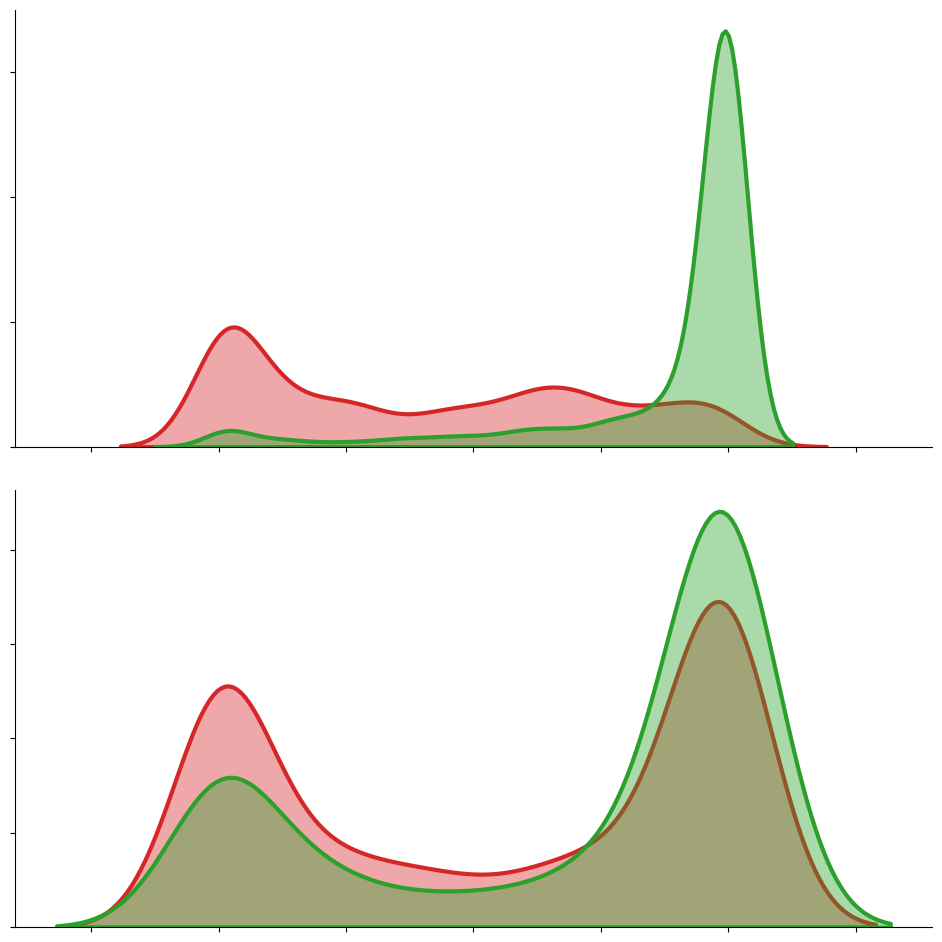

/tmp/ipykernel_1100901/1096198291.py:322: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


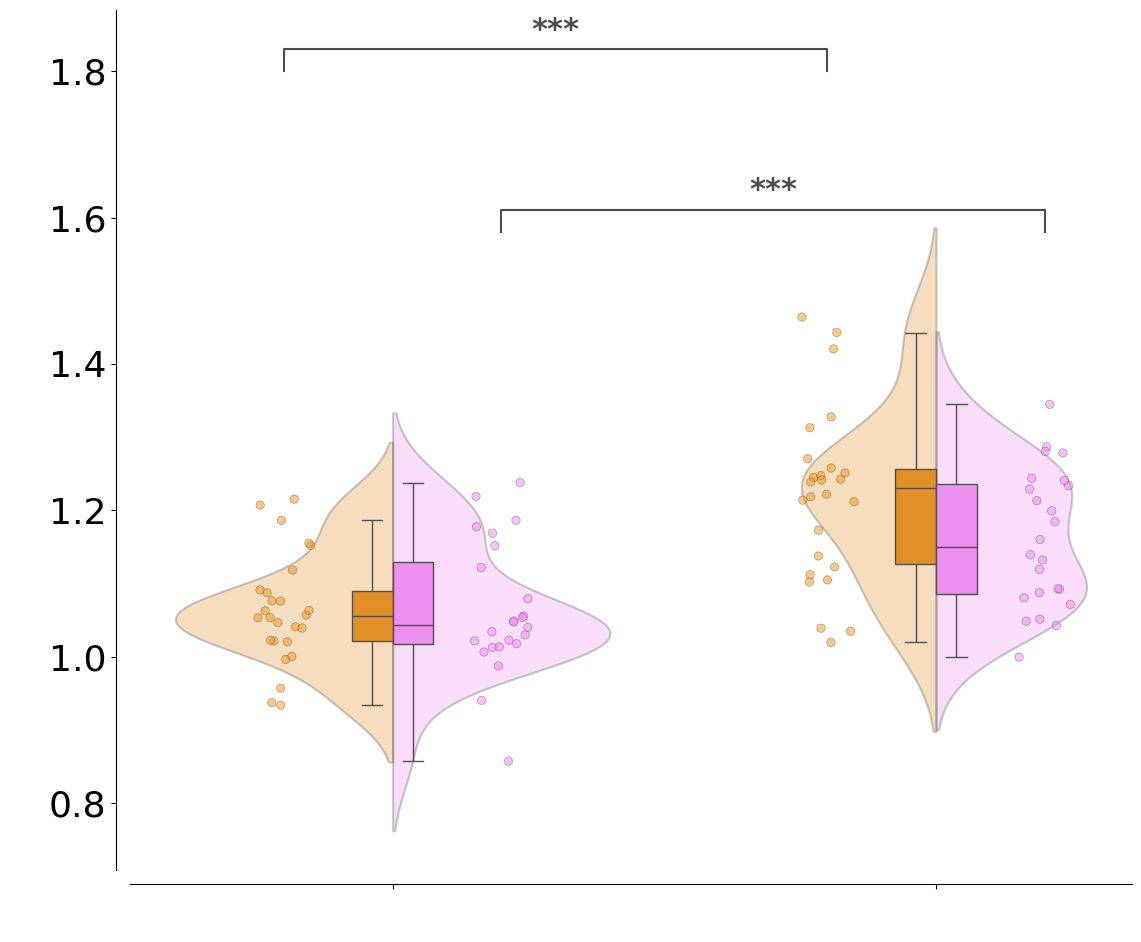

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import pandas as pd
import os
from scipy.stats import wilcoxon

# ============================================================
# 0. Load Data
# ============================================================

input_dir = './indiv_dvals/'
slsqp = True  # Toggle this to apply/remove monotonic constraints

if slsqp:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_slsqp')
    solver_method = 'SLSQP'
else:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_NOslsqp')
    solver_method = 'L-BFGS-B'



df_bif = pd.read_csv(os.path.join(output_dir, 'bifScore.csv'))
df_auc = pd.read_csv(os.path.join(output_dir, 'prediction_auc.csv'))
df_trials = pd.read_csv(os.path.join(output_dir, 'trials.csv'))

# ============================================================
# 1. Figure Parameters
# ============================================================
FS_TITLE  = 24
FS_LABEL  = 24
FS_AXIS_LABEL = FS_LABEL
FS_TICK   = 26
FS_LEGEND = 16
FS_STARS  = 22 
FS_PVAL   = 14   # Increased slightly for readability


PALETTE   = {'active': '#FF9408', 'passive': '#FD80FF'}
ROI_ORDER = ['A1', 'NoA1']

# Strictly 1-sided p-values
SHOW_PVAL_MODE = '1'

VIOLIN_ALPHA  = 0.3
STRIP_ALPHA   = 0.5
STRIP_SIZE    = 6
#SAVE_DPI      = 300

plt.rcParams.update({
    'font.size':        FS_TICK,
    'axes.labelsize':   FS_LABEL,
    'axes.titlesize':   FS_TITLE,
    'xtick.labelsize':  FS_TICK,
    'ytick.labelsize':  FS_TICK,
    'legend.fontsize':  FS_LEGEND,
})

# ============================================================
# 2. Helper Functions
# ============================================================

def get_sig_star(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def format_pval_label(p1, p2, mode):
    """Only returns 1-sided label."""
    return f'p={p1:.3f}' if p1 >= 0.001 else 'p<.001'

def add_bracket(ax, x1, x2, y, h, p1, p2, mode=SHOW_PVAL_MODE):
    star  = get_sig_star(p1)
    #label = format_pval_label(p1, p2, mode)
    label =  ' ' 
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='black')
    ax.text((x1+x2)*.5, y+h, star, ha='center', va='bottom',
            fontsize=FS_STARS, fontweight='bold')
    ax.text((x1+x2)*.5, y+h*2.5, label, ha='center', va='bottom',
            fontsize=FS_PVAL, fontstyle='italic')

def get_paired(df, col_group, val_group1, val_group2, col_subj, col_score, col_filter=None, filter_val=None):
    if col_filter:
        df = df[df[col_filter] == filter_val]
    common = (set(df[df[col_group] == val_group1][col_subj]) &
              set(df[df[col_group] == val_group2][col_subj]))
    a = df[(df[col_group]==val_group1) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    b = df[(df[col_group]==val_group2) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    return a, b

# ============================================================
# 3. Figure 1: Bifurcation Score
# ============================================================

def plot_bifurcation_only(df):
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.violinplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, split=True, inner=None, palette=PALETTE, alpha=VIOLIN_ALPHA, ax=ax,legend=False)
    sns.boxplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, width=0.15, zorder=10, palette=PALETTE, showfliers=False, ax=ax,legend=False)
    sns.stripplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, dodge=True, alpha=STRIP_ALPHA, palette=PALETTE, size=STRIP_SIZE, ax=ax,legend=False)

    ax.axhline(0, color='black', alpha=0.6, lw=2, linestyle='--')
    y_min, y_max = df['score'].min(), df['score'].max()
    pad = (y_max - y_min) * 0.1

    for i, roi in enumerate(ROI_ORDER):
        alt = 'less' if roi == 'A1' else 'greater'
        for j, task in enumerate(['active', 'passive']):
            vals = df[(df['roi']==roi) & (df['task']==task)]['score'].dropna().values
            if len(vals) == 0: continue
            _, p1 = wilcoxon(vals, alternative=alt)
            star = get_sig_star(p1)
            x_pos = i - 0.2 if j == 0 else i + 0.2
            ax.text(x_pos, y_min - pad*1.2, star, ha='center', va='top', fontsize=FS_STARS, fontweight='bold', color=PALETTE[task])
            #ax.text(x_pos, y_min - pad*2.0, f"p={p1:.3f}", ha='center', va='top', fontsize=FS_PVAL, color='#444444')

    for j, task in enumerate(['active', 'passive']):
        a1, no = get_paired(df, 'roi', 'A1', 'NoA1', 'subj', 'score', col_filter='task', filter_val=task)
        if len(a1) == 0: continue
        _, p1 = wilcoxon(no, a1, alternative='greater')
        x_off = -0.2 if j == 0 else 0.2
        add_bracket(ax, 0+x_off, 1+x_off, y_max + pad*(1 + j*3), pad*0.5, p1, None)

    #ax.set_ylabel("Bifurcation Score")
    #ax.set_xlabel("ROI")
    #ax.set_ylim(y_min - pad*4, y_max + pad*9)
    plt.ylabel(' ', fontsize=FS_AXIS_LABEL)
    plt.xlabel(' ', fontsize=FS_AXIS_LABEL)
    frame1 = plt.gca()
    frame1.axes.xaxis.set_ticklabels([])
    #frame1.axes.yaxis.set_ticklabels([])
    sns.despine(offset=10)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_bifurcation2.png'))

    plt.show()

    if ax.get_legend():
        ax.get_legend().remove()
# ============================================================
# 4. Figure 2: AUC Task Comparison
# ============================================================

def plot_auc_comparison(df_auc):
    TASK_ORDER = ['active', 'passive']
    fig, ax = plt.subplots(figsize=(8, 10))
    sns.violinplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, inner=None, alpha=VIOLIN_ALPHA, ax=ax)
    sns.boxplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, width=0.2, palette=PALETTE, showfliers=False, ax=ax)
    sns.stripplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, alpha=STRIP_ALPHA, ax=ax)
    ax.axhline(0.5, color='black', ls='--', lw=2)

    y_min, y_max = df_auc['auc'].min(), df_auc['auc'].max()
    pad = (y_max - y_min) * 0.1

    for i, t in enumerate(TASK_ORDER):
        vals = df_auc[df_auc['task']==t]['auc'].values
        _, p1 = wilcoxon(vals - 0.5, alternative='greater')
        star_str = get_sig_star(p1)
        #p_str = "p < .001" if p1 < 0.001 else f"p = {p1:.3f}"
        #ax.text(i, y_min - pad*1.2, star_str, ha='center', 
                #fontsize=FS_STARS, fontweight='bold', color=PALETTE[t])
        #ax.text(i, y_min - pad*2.2, p_str, ha='center', 
                #fontsize=FS_PVAL, color='black')
        '''ax.text(i, y_min - pad*1.2, get_sig_star(p1), ha='center', fontsize=FS_STARS, fontweight='bold', color=PALETTE[t])
        ax.text(i, y_min - pad*2.0, f"p={p1:.3f}", ha='center', fontsize=FS_PVAL)'''
        #ax.set_ylabel("AUC Score")
        #ax.set_title("Decoding Performance (NoA1)")
        #ax.set_ylim(y_min - pad*4, y_max + pad*6)
    plt.ylabel(' ')
    plt.xlabel(' ')
    frame1 = plt.gca()
    frame1.axes.xaxis.set_ticklabels([])
    #frame1.axes.yaxis.set_ticklabels([])

    act, pas = get_paired(df_auc, 'task', 'active', 'passive', 'subj', 'auc')
    if len(act) > 0:
        _, p1 = wilcoxon(act, pas, alternative='greater')
        add_bracket(ax, 0, 1, y_max + pad*1.5, pad*0.5, p1, None)

    
    sns.despine(offset=10)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_auc_task_compare2.png'))
    plt.show()

    if ax.get_legend():
        ax.get_legend().remove()

# ============================================================
# 5. Figure 3: Posterior Distributions
# ============================================================

def plot_posteriors(df_trials):
    # Use your global font size if defined, otherwise default to 18
    fs_tick = FS_TICK if 'FS_TICK' in globals() else 18
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    df_trials['Report'] = df_trials['HnotH'].map({1.0: 'Heard', 0.0: 'Not Heard'})
    
    for i, task in enumerate(['active', 'passive']):
        sub = df_trials[df_trials['task'] == task]
        
        # Added clip=(0, 1) to prevent the curve from bleeding into negative/impossible values
        sns.kdeplot(data=sub, x='post_high', hue='Report', fill=True,
                    palette={'Heard': '#2ca02c', 'Not Heard': '#d62728'},
                    common_norm=False, ax=axes[i], alpha=0.4, lw=3,
                    legend=False) #, clip=(0, 1))
        
        # Removing titles and axis labels as requested
        axes[i].set_title("")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        
        # Explicitly setting the range to 0-1
        #axes[i].set_xlim(0, 1)
        
        # Ensuring tick labels (the numbers) are visible and sized correctly
        #axes[i].tick_params(axis='x', which='major', labelsize=fs_tick)
        axes[i].yaxis.set_ticklabels([])
        axes[i].xaxis.set_ticklabels([])

    #axes[1].set_xlabel("P(High State | Neural Data)")
    sns.despine()
    plt.tight_layout()
    plt.savefig(
        os.path.join(output_dir, 'group_posterior_distributions3.png'))
    plt.show()

# ============================================================
# Main Execution
# ============================================================
plot_bifurcation_only(df_bif)
plot_auc_comparison(df_auc)
plot_posteriors(df_trials)


###### VPR plot 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

# --- 0. Font Size Toolkit ---
#FS_TITLE = 20
#FS_AXIS_LABEL = 22
#FS_TICKS = 18
#FS_LEGEND = 18
#FS_STARS = 20

FS_TITLE  = 24
FS_AXIS_LABEL  = 24
FS_TICKS   = 24
FS_LEGEND = 16
FS_STARS  = 22
FS_PVAL   = 14   # Increased slightly for readability

# 1. Map the ROI names (Assumes your CSV has 'A1' and 'NoA1')

df_vpr = pd.read_csv('all_vpr_scores_all.csv')

# Apply your mapping
roi_map = {'A1': 'Primary Audit.', 'NoA1': 'Beyond Primary Audit.'}
df_vpr['roi'] = df_vpr['roi'].map(roi_map)


# 2. Formatting setup
roi_order = ['Primary Audit.', 'Beyond Primary Audit.']
task_order = ['active', 'passive']
palette = {'active': '#FF9408', 'passive': '#FD80FF'}



VIOLIN_ALPHA  = 0.3
STRIP_ALPHA   = 0.5
STRIP_SIZE    = 6
#SAVE_DPI      = 300


# --- Statistical Helpers ---
def get_sig_star(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def add_stats_bracket_vpr(ax, x1, x2, y, text):
    # h is the height of the little "arms" of the bracket
    h = (df_vpr['vpr_score'].max() - df_vpr['vpr_score'].min()) * 0.05
    ax.plot([x1, x1, x2, x2], [y-h, y, y, y-h], lw=1.5, c='0.3')
    ax.text((x1+x2)*.5, y + (h*0.2), text, ha='center', va='bottom', 
            color='0.3', fontsize=FS_STARS, fontweight='bold')

# 3. Create the plot
plt.figure(figsize=(12, 10))

# Layer 1: Split Violin
ax = sns.violinplot(
    data=df_vpr, x='roi', y='vpr_score', hue='task',
    hue_order=task_order, order=roi_order,
    split=True, inner=None, palette=palette, alpha=VIOLIN_ALPHA, linewidth=1.5, legend=False
)

# Layer 2: Box Plot (Fixed: Removed boxprops to avoid UnboundLocalError)
sns.boxplot(
    data=df_vpr, x='roi', y='vpr_score', hue='task',
    hue_order=task_order, order=roi_order,
    width=0.15, zorder=10, palette=palette,
    showcaps=True, showfliers=False, ax=ax,legend=False
)


# Apply manual boxplot styling (Empty face, dark edges)
for patch in ax.patches:
    if isinstance(patch, plt.Polygon):
        patch.set_facecolor('none')
        patch.set_edgecolor('0.3')

# Layer 3: Strip Plot
sns.stripplot(
    data=df_vpr, x='roi', y='vpr_score', hue='task',
    hue_order=task_order, order=roi_order,
    dodge=True, jitter=True, alpha=STRIP_ALPHA, palette=palette,
    size=STRIP_SIZE, edgecolor='gray', linewidth=0.5, ax=ax,legend=False
)

# --- 4. STATS: Comparison Between Regions (A1 vs NoA1) ---
y_max = df_vpr['vpr_score'].max()

for task_idx, task in enumerate(task_order):
    g1 = df_vpr[(df_vpr['roi'] == roi_order[0]) & (df_vpr['task'] == task)]['vpr_score'].dropna()
    g2 = df_vpr[(df_vpr['roi'] == roi_order[1]) & (df_vpr['task'] == task)]['vpr_score'].dropna()
    
    stat, p_val = ttest_rel(g1, g2)
    star_text = get_sig_star(p_val)
    
    # Calculate x-positions for the bracket
    x1 = 0 - 0.2 if task == 'passive' else 0 + 0.2
    x2 = 1 - 0.2 if task == 'passive' else 1 + 0.2
    
    # Position bracket above the max value
    bracket_y = y_max * (1.1 + task_idx * 0.15)
    add_stats_bracket_vpr(ax, x1, x2, bracket_y, star_text)

# --- 5. Final Touches ---
# Reference line at 1.0 (indicating no variability peak)
#plt.axhline(1, color='black', linestyle='--', alpha=0.5, lw=2, label='No Variability Peak')

#plt.title('Variability Peak Ratio (VPR) across ROIs', fontsize=FS_TITLE, pad=25)
plt.ylabel(' ', fontsize=FS_AXIS_LABEL)
plt.xlabel(' ', fontsize=FS_AXIS_LABEL)
frame1 = plt.gca()
frame1.axes.xaxis.set_ticklabels([])
#frame1.axes.yaxis.set_ticklabels([])


#ax = frame1

#ax.spines['left'].set_linewidth(2.0)
#ax.spines['bottom'].set_linewidth(2.0)

sns.despine(offset=10)
plt.tight_layout()
plt.savefig('grp_comparison_VPR2.png', dpi=300)
plt.show()

# load data and plot (1)

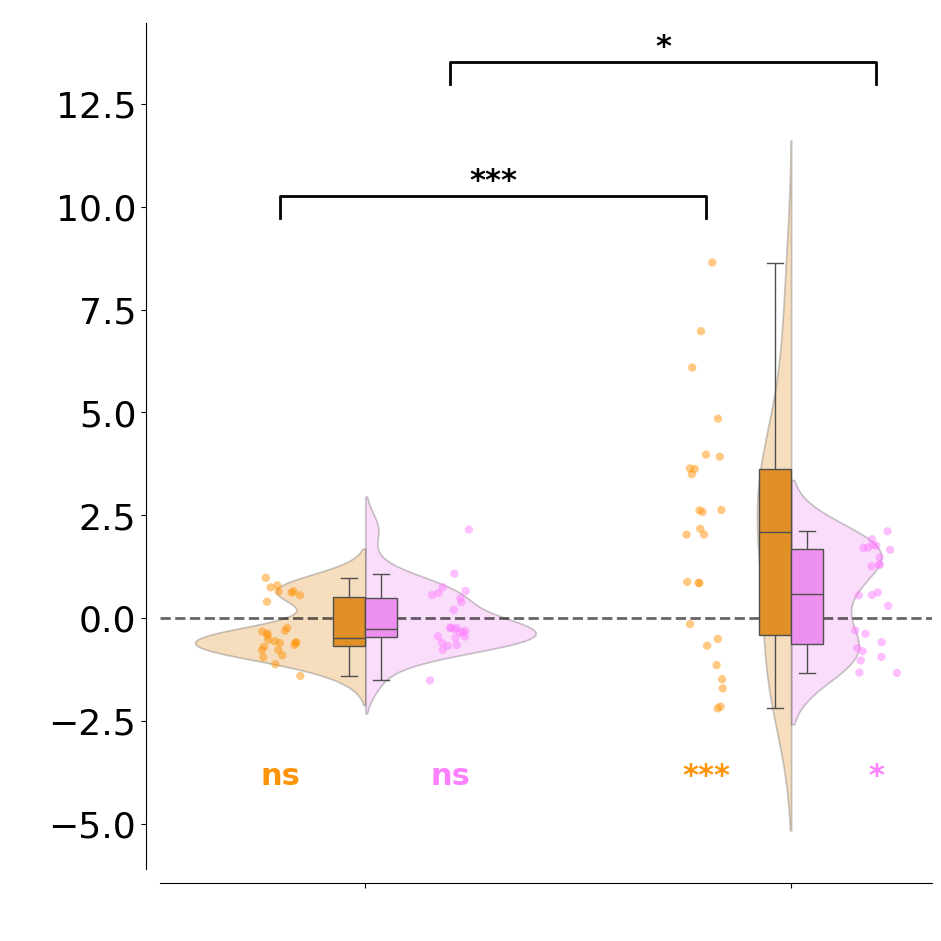

/tmp/ipykernel_1100901/2503636029.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, inner=None, alpha=VIOLIN_ALPHA, ax=ax)
/tmp/ipykernel_1100901/2503636029.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, width=0.2, palette=PALETTE, showfliers=False, ax=ax)
/tmp/ipykernel_1100901/2503636029.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, al

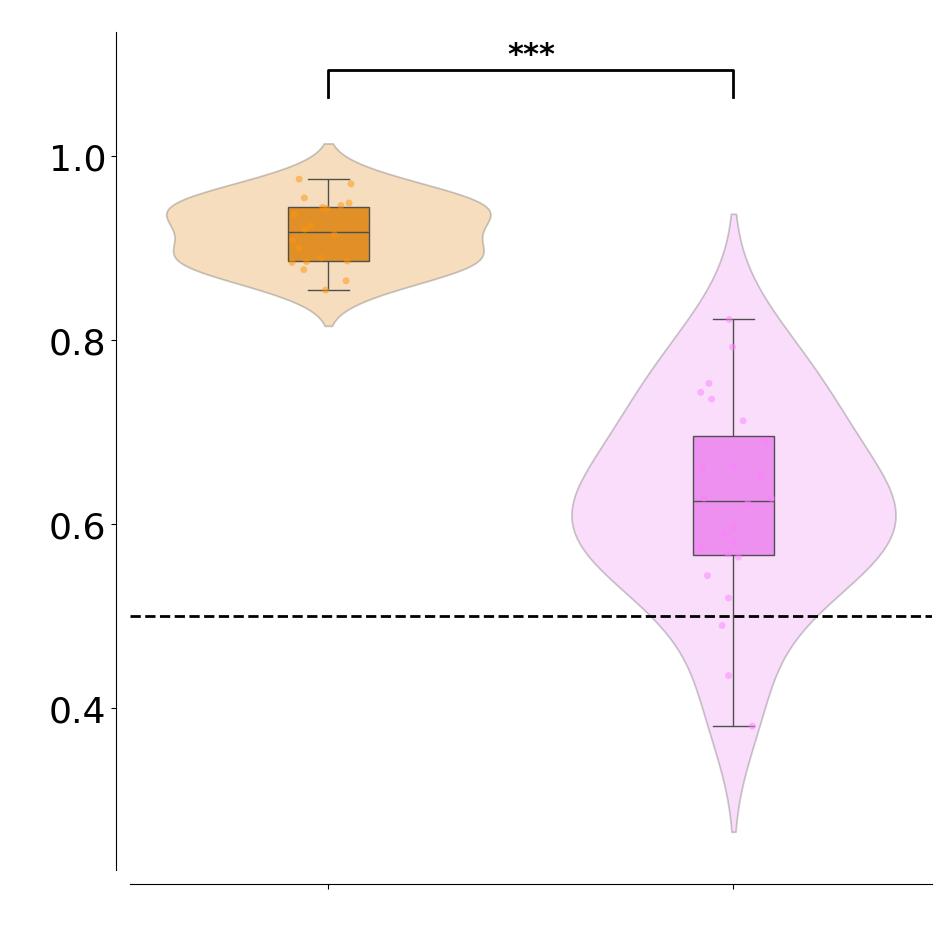

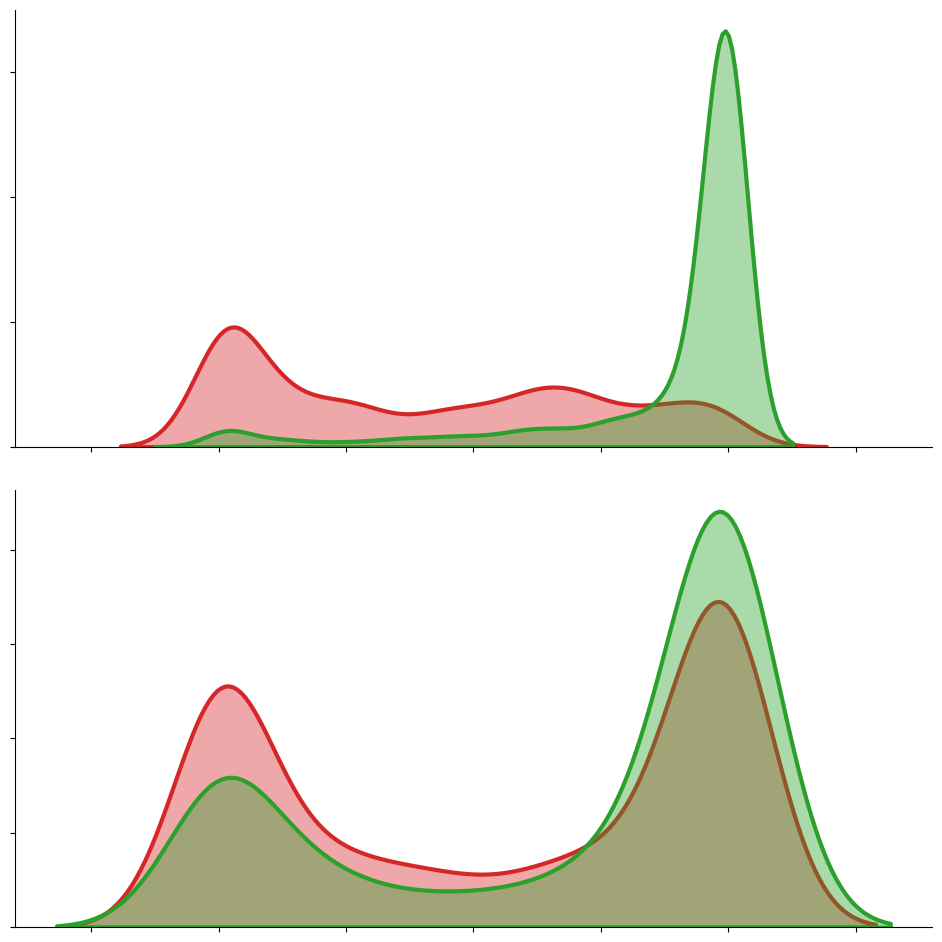

/tmp/ipykernel_1100901/2503636029.py:223: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,


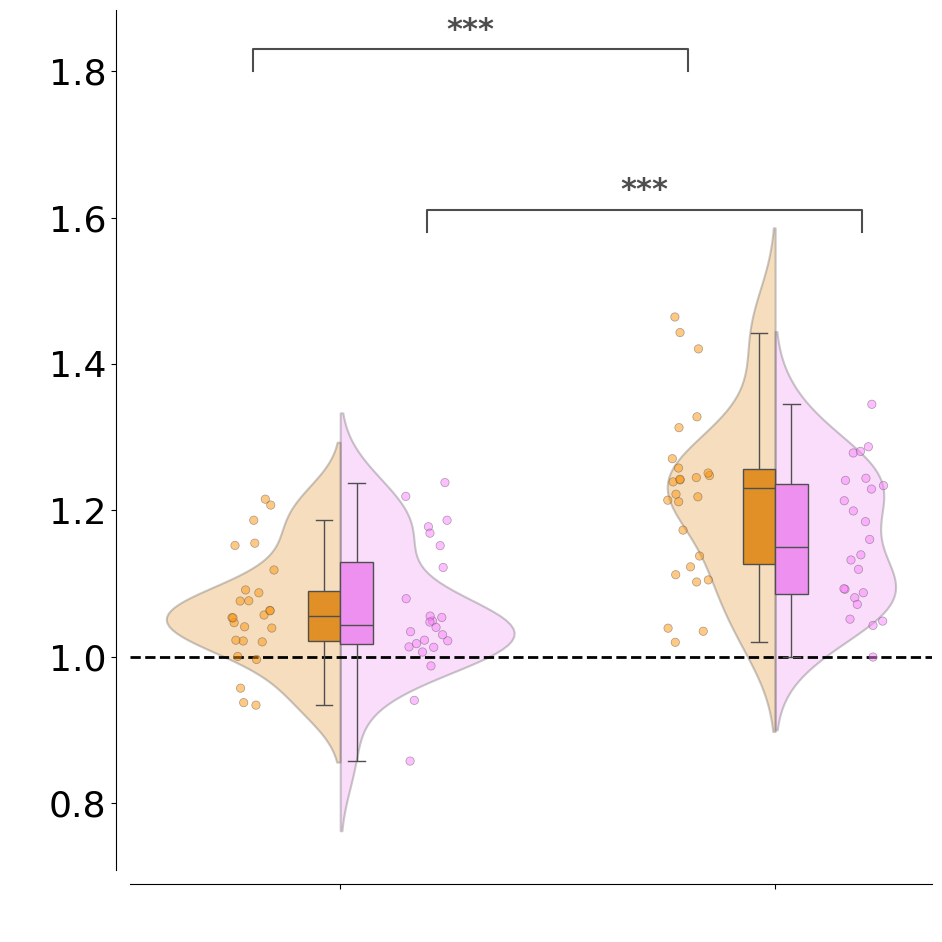

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import pandas as pd
import os
from scipy.stats import wilcoxon

# ============================================================
# 0. Load Data
# ============================================================

input_dir = './indiv_dvals/'
slsqp = True  # Toggle this to apply/remove monotonic constraints

if slsqp:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_slsqp')
    solver_method = 'SLSQP'
else:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_NOslsqp')
    solver_method = 'L-BFGS-B'

df_bif = pd.read_csv(os.path.join(output_dir, 'bifScore.csv'))
df_auc = pd.read_csv(os.path.join(output_dir, 'prediction_auc.csv'))
df_trials = pd.read_csv(os.path.join(output_dir, 'trials.csv'))

# ============================================================
# 1. Figure Parameters (Homogenized)
# ============================================================
FS_TITLE  = 24
FS_LABEL  = 24
FS_AXIS_LABEL = FS_LABEL
FS_TICK   = 26
FS_LEGEND = 16
FS_STARS  = 22 
FS_PVAL   = 14   

PALETTE   = {'active': '#FF9408', 'passive': '#FD80FF'}
ROI_ORDER = ['A1', 'NoA1']
SHOW_PVAL_MODE = '1'
VIOLIN_ALPHA  = 0.3
STRIP_ALPHA   = 0.5
STRIP_SIZE    = 6

plt.rcParams.update({
    'font.size':         FS_TICK,
    'axes.labelsize':    FS_LABEL,
    'axes.titlesize':    FS_TITLE,
    'xtick.labelsize':   FS_TICK,
    'ytick.labelsize':   FS_TICK,
    'legend.fontsize':   FS_LEGEND,
})

# ============================================================
# 2. Helper Functions
# ============================================================

def get_sig_star(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def format_pval_label(p1, p2, mode):
    return f'p={p1:.3f}' if p1 >= 0.001 else 'p<.001'

def add_bracket(ax, x1, x2, y, h, p1, p2, mode=SHOW_PVAL_MODE):
    star  = get_sig_star(p1)
    label =  ' ' 
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='black')
    ax.text((x1+x2)*.5, y+h, star, ha='center', va='bottom',
            fontsize=FS_STARS, fontweight='bold')
    ax.text((x1+x2)*.5, y+h*2.5, label, ha='center', va='bottom',
            fontsize=FS_PVAL, fontstyle='italic')

def get_paired(df, col_group, val_group1, val_group2, col_subj, col_score, col_filter=None, filter_val=None):
    if col_filter:
        df = df[df[col_filter] == filter_val]
    common = (set(df[df[col_group] == val_group1][col_subj]) &
              set(df[df[col_group] == val_group2][col_subj]))
    a = df[(df[col_group]==val_group1) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    b = df[(df[col_group]==val_group2) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    return a, b

# ============================================================
# 3. Figure 1: Bifurcation Score
# ============================================================

def plot_bifurcation_only(df):
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.violinplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, split=True, inner=None, palette=PALETTE, alpha=VIOLIN_ALPHA, ax=ax,legend=False)
    sns.boxplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, width=0.15, zorder=10, palette=PALETTE, showfliers=False, ax=ax,legend=False)
    sns.stripplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, dodge=True, alpha=STRIP_ALPHA, palette=PALETTE, size=STRIP_SIZE, ax=ax,legend=False)

    ax.axhline(0, color='black', alpha=0.6, lw=2, linestyle='--')
    y_min, y_max = df['score'].min(), df['score'].max()
    pad = (y_max - y_min) * 0.1

    for i, roi in enumerate(ROI_ORDER):
        alt = 'less' if roi == 'A1' else 'greater'
        for j, task in enumerate(['active', 'passive']):
            vals = df[(df['roi']==roi) & (df['task']==task)]['score'].dropna().values
            if len(vals) == 0: continue
            _, p1 = wilcoxon(vals, alternative=alt)
            star = get_sig_star(p1)
            x_pos = i - 0.2 if j == 0 else i + 0.2
            ax.text(x_pos, y_min - pad*1.2, star, ha='center', va='top', fontsize=FS_STARS, fontweight='bold', color=PALETTE[task])

    for j, task in enumerate(['active', 'passive']):
        a1, no = get_paired(df, 'roi', 'A1', 'NoA1', 'subj', 'score', col_filter='task', filter_val=task)
        if len(a1) == 0: continue
        _, p1 = wilcoxon(no, a1, alternative='greater')
        x_off = -0.2 if j == 0 else 0.2
        add_bracket(ax, 0+x_off, 1+x_off, y_max + pad*(1 + j*3), pad*0.5, p1, None)

    plt.ylabel(' ', fontsize=FS_AXIS_LABEL)
    plt.xlabel(' ', fontsize=FS_AXIS_LABEL)
    frame1 = plt.gca()
    frame1.axes.xaxis.set_ticklabels([])
    sns.despine(offset=10)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_bifurcation2.png'))
    plt.show()

# ============================================================
# 4. Figure 2: AUC Task Comparison
# ============================================================

def plot_auc_comparison(df_auc):
    TASK_ORDER = ['active', 'passive']
    fig, ax = plt.subplots(figsize=(10, 10)) # Homogenized to 10x10
    sns.violinplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, inner=None, alpha=VIOLIN_ALPHA, ax=ax)
    sns.boxplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, width=0.2, palette=PALETTE, showfliers=False, ax=ax)
    sns.stripplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, alpha=STRIP_ALPHA, ax=ax)
    ax.axhline(0.5, color='black', ls='--', lw=2)

    y_min, y_max = df_auc['auc'].min(), df_auc['auc'].max()
    pad = (y_max - y_min) * 0.1

    plt.ylabel(' ')
    plt.xlabel(' ')
    frame1 = plt.gca()
    frame1.axes.xaxis.set_ticklabels([])

    act, pas = get_paired(df_auc, 'task', 'active', 'passive', 'subj', 'auc')
    if len(act) > 0:
        _, p1 = wilcoxon(act, pas, alternative='greater')
        add_bracket(ax, 0, 1, y_max + pad*1.5, pad*0.5, p1, None)
    
    sns.despine(offset=10)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_auc_task_compare2.png'))
    plt.show()

# ============================================================
# 5. Figure 3: Posterior Distributions
# ============================================================

def plot_posteriors(df_trials):
    fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    df_trials['Report'] = df_trials['HnotH'].map({1.0: 'Heard', 0.0: 'Not Heard'})
    
    for i, task in enumerate(['active', 'passive']):
        sub = df_trials[df_trials['task'] == task]
        sns.kdeplot(data=sub, x='post_high', hue='Report', fill=True,
                    palette={'Heard': '#2ca02c', 'Not Heard': '#d62728'},
                    common_norm=False, ax=axes[i], alpha=0.4, lw=3,
                    legend=False) #, clip=(0, 1)) # Applied correction
        
        axes[i].set_title("")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        #axes[i].set_xlim(0, 1) # Applied correction
        axes[i].yaxis.set_ticklabels([])
        axes[i].xaxis.set_ticklabels([])

    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_posterior_distributions3.png'))
    plt.show()

# ============================================================
# Main Execution
# ============================================================
plot_bifurcation_only(df_bif)
plot_auc_comparison(df_auc)
plot_posteriors(df_trials)

# ============================================================
# VPR plot Homogenization
# ============================================================
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_rel

df_vpr = pd.read_csv('all_vpr_scores_all.csv')
roi_map = {'A1': 'Primary Audit.', 'NoA1': 'Beyond Primary Audit.'}
df_vpr['roi'] = df_vpr['roi'].map(roi_map)

roi_order = ['Primary Audit.', 'Beyond Primary Audit.']
task_order = ['active', 'passive']
palette = {'active': '#FF9408', 'passive': '#FD80FF'}

def add_stats_bracket_vpr(ax, x1, x2, y, text):
    h = (df_vpr['vpr_score'].max() - df_vpr['vpr_score'].min()) * 0.05
    ax.plot([x1, x1, x2, x2], [y-h, y, y, y-h], lw=1.5, c='0.3')
    ax.text((x1+x2)*.5, y + (h*0.2), text, ha='center', va='bottom', 
            color='0.3', fontsize=FS_STARS, fontweight='bold')

plt.figure(figsize=(10, 10)) # Homogenized to 10x10

ax = sns.violinplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,
    split=True, inner=None, palette=palette, alpha=VIOLIN_ALPHA, linewidth=1.5, legend=False)

sns.boxplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,
    width=0.15, zorder=10, palette=palette, showcaps=True, showfliers=False, ax=ax,legend=False)

for patch in ax.patches:
    if isinstance(patch, plt.Polygon):
        patch.set_facecolor('none')
        patch.set_edgecolor('0.3')

sns.stripplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,
    dodge=True, jitter=True, alpha=STRIP_ALPHA, palette=palette, size=STRIP_SIZE, edgecolor='gray', linewidth=0.5, ax=ax,legend=False)

y_max = df_vpr['vpr_score'].max()
for task_idx, task in enumerate(task_order):
    g1 = df_vpr[(df_vpr['roi'] == roi_order[0]) & (df_vpr['task'] == task)]['vpr_score'].dropna()
    g2 = df_vpr[(df_vpr['roi'] == roi_order[1]) & (df_vpr['task'] == task)]['vpr_score'].dropna()
    stat, p_val = ttest_rel(g1, g2)
    star_text = get_sig_star(p_val)
    x1, x2 = (0 - 0.2 if task == 'passive' else 0 + 0.2), (1 - 0.2 if task == 'passive' else 1 + 0.2)
    bracket_y = y_max * (1.1 + task_idx * 0.15)
    add_stats_bracket_vpr(ax, x1, x2, bracket_y, star_text)

ax.axhline(1, color='black', ls='--', lw=2)
plt.ylabel(' ', fontsize=FS_AXIS_LABEL)
plt.xlabel(' ', fontsize=FS_AXIS_LABEL)
plt.gca().axes.xaxis.set_ticklabels([])
sns.despine(offset=10)
plt.tight_layout()
plt.savefig('grp_comparison_VPR2.png', dpi=300)
plt.show()

In [3]:
import pandas as pd
import numpy as np
import os
from scipy.stats import wilcoxon

# ============================================================
# 1. Configuration
# ============================================================
# Toggle this to match the folder you want to analyze
apply_slsqp_constraints = True 

if apply_slsqp_constraints:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_slsqp')
    folder_label = "SLSQP (Monotonic Constraints Applied)"
else:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_NOslsqp')
    folder_label = "L-BFGS-B (No Monotonic Constraints)"

# ============================================================
# 2. Helper Functions
# ============================================================

def get_paired(df, col_group, val_group1, val_group2, col_subj, col_score, col_filter=None, filter_val=None):
    """
    Ensures subjects are matched between two groups for paired statistical testing.
    """
    if col_filter:
        df = df[df[col_filter] == filter_val]
    
    # Find subjects present in both groups
    common = (set(df[df[col_group] == val_group1][col_subj]) &
              set(df[df[col_group] == val_group2][col_subj]))
    
    a = df[(df[col_group]==val_group1) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    b = df[(df[col_group]==val_group2) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    return a, b

# ============================================================
# 3. Main Execution
# ============================================================

def run_stats_report():
    print("="*70)
    print(f"REPORT FOR: {folder_label}")
    print("="*70)

    # File Paths
    bif_path = os.path.join(output_dir, 'bifScore.csv')
    auc_path = os.path.join(output_dir, 'prediction_auc.csv')

    # Load Data
    if not os.path.exists(bif_path) or not os.path.exists(auc_path):
        print(f"❌ Error: Files not found in {output_dir}")
        print("Please ensure you have run the main processing script first.")
        return

    df_bif = pd.read_csv(bif_path)
    df_auc = pd.read_csv(auc_path)

    # --- Section 1: Bifurcation Scores vs Chance ---
    print("\n[SECTION 1] BIFURCATION SCORES VS. CHANCE (0)")
    print("-" * 50)
    # A1 hypothesis: Unimodal (Score < 0)
    # NoA1 hypothesis: Bimodal (Score > 0)
    
    for roi in ['A1', 'NoA1']:
        alt_test = 'less' if roi == 'A1' else 'greater'
        for task in ['active', 'passive']:
            subset = df_bif[(df_bif['roi'] == roi) & (df_bif['task'] == task)]['score'].dropna()
            m, sd = subset.mean(), subset.std()
            _, p = wilcoxon(subset, alternative=alt_test)
            
            sig_status = "SIGNIFICANT" if p < 0.05 else "not significant"
            print(f"{roi:<5} | {task.capitalize():<8}: Mean={m:6.3f} (SD={sd:.3f}) | p={p:.4f} ({sig_status})")

    # --- Section 2: ROI Comparisons (NoA1 vs A1) ---
    print("\n[SECTION 2] ROI COMPARISON: NoA1 > A1")
    print("-" * 50)
    for task in ['active', 'passive']:
        a1_vals, noa1_vals = get_paired(df_bif, 'roi', 'A1', 'NoA1', 'subj', 'score', col_filter='task', filter_val=task)
        if len(a1_vals) > 0:
            _, p = wilcoxon(noa1_vals, a1_vals, alternative='greater')
            print(f"{task.capitalize():<8}: NoA1 vs A1 | p={p:.4f}")

    # --- Section 3: VPR Summary ---
    print("\n[SECTION 3] VPR (VARIABILITY-TO-PEAK RATIO)")
    print("-" * 50)
    vpr_summary = df_bif.groupby(['roi', 'task'])['vpr_fulldata'].agg(['mean', 'std']).reset_index()
    for _, row in vpr_summary.iterrows():
        print(f"{row['roi']:<5} | {row['task']:<8}: Mean VPR={row['mean']:.3f} (SD={row['std']:.3f})")

    # --- Section 4: Behavioral Decoding (AUC) ---
    print("\n[SECTION 4] DECODING PERFORMANCE (AUC)")
    print("-" * 50)
    for task in ['active', 'passive']:
        auc_vals = df_auc[df_auc['task'] == task]['auc'].dropna()
        m, sd = auc_vals.mean(), auc_vals.std()
        # Test against chance level (0.5)
        _, p = wilcoxon(auc_vals - 0.5, alternative='greater')
        
        print(f"{task.capitalize():<8}: Mean AUC={m:.3f} (SD={sd:.3f}) | p={p:.4f} vs Chance")

    # --- Section 5: Task Comparison (Active vs Passive AUC) ---
    print("\n[SECTION 5] TASK COMPARISON: Active > Passive (AUC)")
    print("-" * 50)
    act_auc, pas_auc = get_paired(df_auc, 'task', 'active', 'passive', 'subj', 'auc')
    if len(act_auc) > 0:
        _, p = wilcoxon(act_auc, pas_auc, alternative='greater')
        print(f"Active vs Passive AUC: p={p:.4f}")

    print("\n" + "="*70)
    print("Report Generation Complete.")

if __name__ == "__main__":
    run_stats_report()

REPORT FOR: SLSQP (Monotonic Constraints Applied)

[SECTION 1] BIFURCATION SCORES VS. CHANCE (0)
--------------------------------------------------
A1    | Active  : Mean=-0.252 (SD=0.681) | p=0.0750 (not significant)
A1    | Passive : Mean=-0.034 (SD=0.759) | p=0.3317 (not significant)
NoA1  | Active  : Mean= 1.991 (SD=2.848) | p=0.0008 (SIGNIFICANT)
NoA1  | Passive : Mean= 0.520 (SD=1.178) | p=0.0228 (SIGNIFICANT)

[SECTION 2] ROI COMPARISON: NoA1 > A1
--------------------------------------------------
Active  : NoA1 vs A1 | p=0.0004
Passive : NoA1 vs A1 | p=0.0323

[SECTION 3] VPR (VARIABILITY-TO-PEAK RATIO)
--------------------------------------------------
A1    | active  : Mean VPR=1.064 (SD=0.075)
A1    | passive : Mean VPR=1.064 (SD=0.090)
NoA1  | active  : Mean VPR=1.218 (SD=0.117)
NoA1  | passive : Mean VPR=1.161 (SD=0.094)

[SECTION 4] DECODING PERFORMANCE (AUC)
--------------------------------------------------
Active  : Mean AUC=0.917 (SD=0.035) | p=0.0000 vs Chance
Passiv

# VPR

/tmp/ipykernel_1100901/3268610851.py:82: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


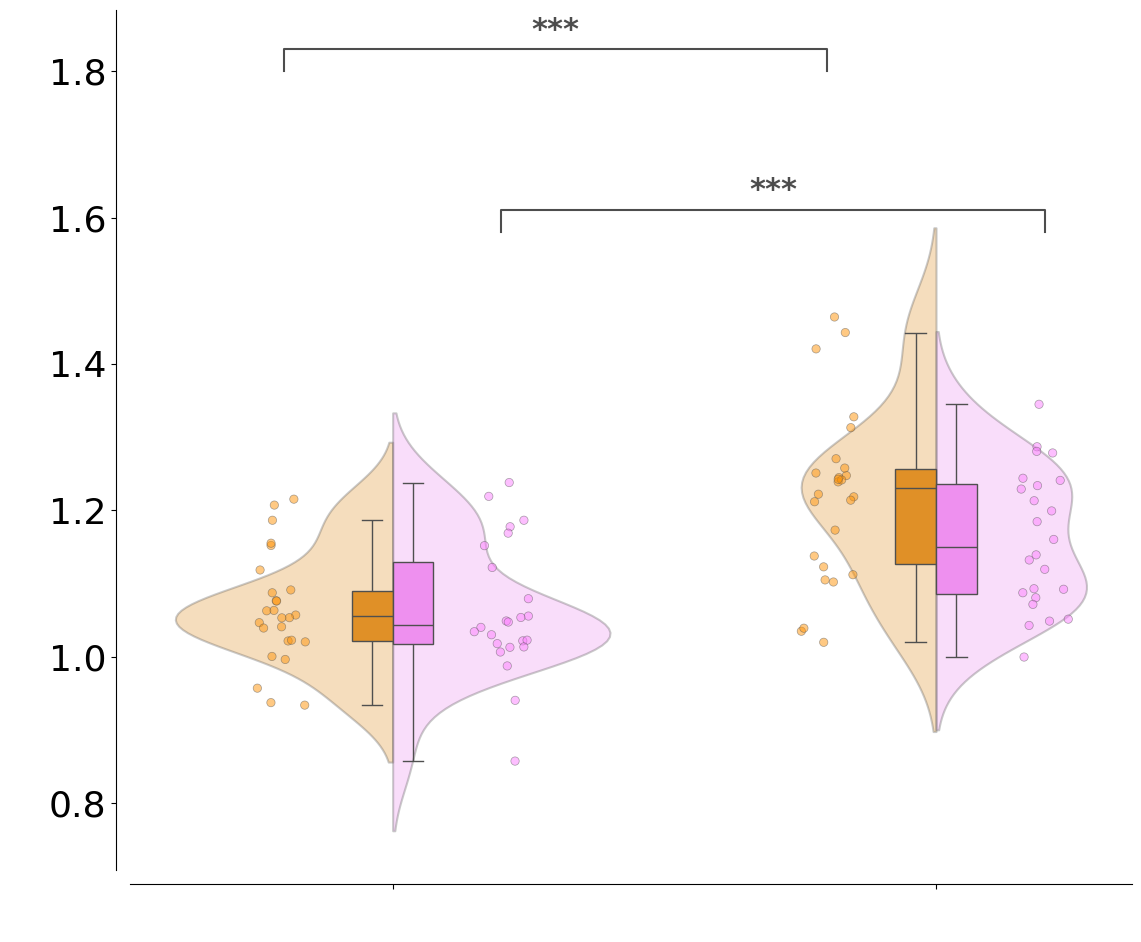

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

# --- 0. Font Size Toolkit ---
#FS_TITLE = 20
#FS_AXIS_LABEL = 22
#FS_TICKS = 18
#FS_LEGEND = 18
#FS_STARS = 20

FS_TITLE  = 24
FS_AXIS_LABEL  = 24
FS_TICKS   = 24
FS_LEGEND = 16
FS_STARS  = 22
FS_PVAL   = 14   # Increased slightly for readability

# 1. Map the ROI names (Assumes your CSV has 'A1' and 'NoA1')

df_vpr = pd.read_csv('all_vpr_scores_all.csv')

# Apply your mapping
roi_map = {'A1': 'Primary Audit.', 'NoA1': 'Beyond Primary Audit.'}
df_vpr['roi'] = df_vpr['roi'].map(roi_map)


# 2. Formatting setup
roi_order = ['Primary Audit.', 'Beyond Primary Audit.']
task_order = ['active', 'passive']
palette = {'active': '#FF9408', 'passive': '#FD80FF'}



VIOLIN_ALPHA  = 0.3
STRIP_ALPHA   = 0.5
STRIP_SIZE    = 6
#SAVE_DPI      = 300


# --- Statistical Helpers ---
def get_sig_star(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def add_stats_bracket_vpr(ax, x1, x2, y, text):
    # h is the height of the little "arms" of the bracket
    h = (df_vpr['vpr_score'].max() - df_vpr['vpr_score'].min()) * 0.05
    ax.plot([x1, x1, x2, x2], [y-h, y, y, y-h], lw=1.5, c='0.3')
    ax.text((x1+x2)*.5, y + (h*0.2), text, ha='center', va='bottom', 
            color='0.3', fontsize=FS_STARS, fontweight='bold')

# 3. Create the plot
plt.figure(figsize=(12, 10))

# Layer 1: Split Violin
ax = sns.violinplot(
    data=df_vpr, x='roi', y='vpr_score', hue='task',
    hue_order=task_order, order=roi_order,
    split=True, inner=None, palette=palette, alpha=VIOLIN_ALPHA, linewidth=1.5, legend=False
)

# Layer 2: Box Plot (Fixed: Removed boxprops to avoid UnboundLocalError)
sns.boxplot(
    data=df_vpr, x='roi', y='vpr_score', hue='task',
    hue_order=task_order, order=roi_order,
    width=0.15, zorder=10, palette=palette,
    showcaps=True, showfliers=False, ax=ax,legend=False
)


# Apply manual boxplot styling (Empty face, dark edges)
for patch in ax.patches:
    if isinstance(patch, plt.Polygon):
        patch.set_facecolor('none')
        patch.set_edgecolor('0.3')

# Layer 3: Strip Plot
sns.stripplot(
    data=df_vpr, x='roi', y='vpr_score', hue='task',
    hue_order=task_order, order=roi_order,
    dodge=True, jitter=True, alpha=STRIP_ALPHA, palette=palette,
    size=STRIP_SIZE, edgecolor='gray', linewidth=0.5, ax=ax,legend=False
)

# --- 4. STATS: Comparison Between Regions (A1 vs NoA1) ---
y_max = df_vpr['vpr_score'].max()

for task_idx, task in enumerate(task_order):
    g1 = df_vpr[(df_vpr['roi'] == roi_order[0]) & (df_vpr['task'] == task)]['vpr_score'].dropna()
    g2 = df_vpr[(df_vpr['roi'] == roi_order[1]) & (df_vpr['task'] == task)]['vpr_score'].dropna()
    
    stat, p_val = ttest_rel(g1, g2)
    star_text = get_sig_star(p_val)
    
    # Calculate x-positions for the bracket
    x1 = 0 - 0.2 if task == 'passive' else 0 + 0.2
    x2 = 1 - 0.2 if task == 'passive' else 1 + 0.2
    
    # Position bracket above the max value
    bracket_y = y_max * (1.1 + task_idx * 0.15)
    add_stats_bracket_vpr(ax, x1, x2, bracket_y, star_text)

# --- 5. Final Touches ---
# Reference line at 1.0 (indicating no variability peak)
#plt.axhline(1, color='black', linestyle='--', alpha=0.5, lw=2, label='No Variability Peak')

#plt.title('Variability Peak Ratio (VPR) across ROIs', fontsize=FS_TITLE, pad=25)
plt.ylabel(' ', fontsize=FS_AXIS_LABEL)
plt.xlabel(' ', fontsize=FS_AXIS_LABEL)
frame1 = plt.gca()
frame1.axes.xaxis.set_ticklabels([])
#frame1.axes.yaxis.set_ticklabels([])


#ax = frame1

#ax.spines['left'].set_linewidth(2.0)
#ax.spines['bottom'].set_linewidth(2.0)

sns.despine(offset=10)
plt.tight_layout()
plt.savefig('grp_comparison_VPR2.png', dpi=300)
plt.show()

# load data and plot (2)

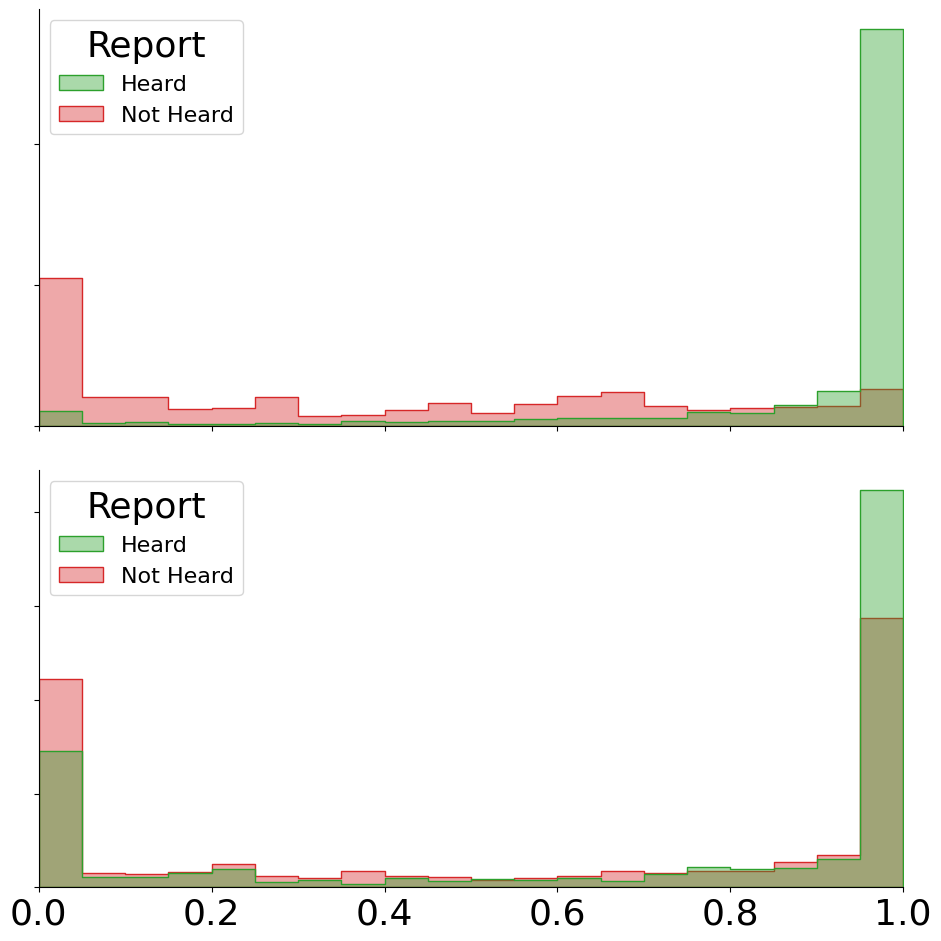

"import pandas as pd\nimport seaborn as sns\nfrom scipy.stats import ttest_rel\n\ndf_vpr = pd.read_csv('all_vpr_scores_all.csv')\nroi_map = {'A1': 'Primary Audit.', 'NoA1': 'Beyond Primary Audit.'}\ndf_vpr['roi'] = df_vpr['roi'].map(roi_map)\n\nroi_order = ['Primary Audit.', 'Beyond Primary Audit.']\ntask_order = ['active', 'passive']\npalette = {'active': '#FF9408', 'passive': '#FD80FF'}\n\ndef add_stats_bracket_vpr(ax, x1, x2, y, text):\n    h = (df_vpr['vpr_score'].max() - df_vpr['vpr_score'].min()) * 0.05\n    ax.plot([x1, x1, x2, x2], [y-h, y, y, y-h], lw=1.5, c='0.3')\n    ax.text((x1+x2)*.5, y + (h*0.2), text, ha='center', va='bottom', \n            color='0.3', fontsize=FS_STARS, fontweight='bold')\n\nplt.figure(figsize=(10, 10)) # Homogenized to 10x10\n\nax = sns.violinplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,\n    split=True, inner=None, palette=palette, alpha=VIOLIN_ALPHA, linewidth=1.5, legend=False)\n\nsns.boxplot(data=df_

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import pandas as pd
import os
from scipy.stats import wilcoxon

# ============================================================
# 0. Load Data
# ============================================================

input_dir = './indiv_dvals/'
slsqp = True  # Toggle this to apply/remove monotonic constraints

if slsqp:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_slsqp')
    solver_method = 'SLSQP'
else:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_NOslsqp')
    solver_method = 'L-BFGS-B'

df_bif = pd.read_csv(os.path.join(output_dir, 'bifScore.csv'))
df_auc = pd.read_csv(os.path.join(output_dir, 'prediction_auc.csv'))
df_trials = pd.read_csv(os.path.join(output_dir, 'trials.csv'))

# ============================================================
# 1. Figure Parameters (Homogenized)
# ============================================================
FS_TITLE  = 24
FS_LABEL  = 24
FS_AXIS_LABEL = FS_LABEL
FS_TICK   = 26
FS_LEGEND = 16
FS_STARS  = 22 
FS_PVAL   = 14   

PALETTE   = {'active': '#FF9408', 'passive': '#FD80FF'}
ROI_ORDER = ['A1', 'NoA1']
SHOW_PVAL_MODE = '1'
VIOLIN_ALPHA  = 0.3
STRIP_ALPHA   = 0.5
STRIP_SIZE    = 6

plt.rcParams.update({
    'font.size':         FS_TICK,
    'axes.labelsize':    FS_LABEL,
    'axes.titlesize':    FS_TITLE,
    'xtick.labelsize':   FS_TICK,
    'ytick.labelsize':   FS_TICK,
    'legend.fontsize':   FS_LEGEND,
})

# ============================================================
# 2. Helper Functions
# ============================================================

def get_sig_star(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def format_pval_label(p1, p2, mode):
    return f'p={p1:.3f}' if p1 >= 0.001 else 'p<.001'

def add_bracket(ax, x1, x2, y, h, p1, p2, mode=SHOW_PVAL_MODE):
    star  = get_sig_star(p1)
    label =  ' ' 
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='black')
    ax.text((x1+x2)*.5, y+h, star, ha='center', va='bottom',
            fontsize=FS_STARS, fontweight='bold')
    ax.text((x1+x2)*.5, y+h*2.5, label, ha='center', va='bottom',
            fontsize=FS_PVAL, fontstyle='italic')

def get_paired(df, col_group, val_group1, val_group2, col_subj, col_score, col_filter=None, filter_val=None):
    if col_filter:
        df = df[df[col_filter] == filter_val]
    common = (set(df[df[col_group] == val_group1][col_subj]) &
              set(df[df[col_group] == val_group2][col_subj]))
    a = df[(df[col_group]==val_group1) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    b = df[(df[col_group]==val_group2) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    return a, b

# ============================================================
# 3. Figure 1: Bifurcation Score
# ============================================================

def plot_bifurcation_only(df):
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.violinplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, split=True, inner=None, palette=PALETTE, alpha=VIOLIN_ALPHA, ax=ax,legend=False)
    sns.boxplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, width=0.15, zorder=10, palette=PALETTE, showfliers=False, ax=ax,legend=False)
    sns.stripplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, dodge=True, alpha=STRIP_ALPHA, palette=PALETTE, size=STRIP_SIZE, ax=ax,legend=False)

    ax.axhline(0, color='black', alpha=0.6, lw=2, linestyle='--')
    y_min, y_max = df['score'].min(), df['score'].max()
    pad = (y_max - y_min) * 0.1

    for i, roi in enumerate(ROI_ORDER):
        alt = 'less' if roi == 'A1' else 'greater'
        for j, task in enumerate(['active', 'passive']):
            vals = df[(df['roi']==roi) & (df['task']==task)]['score'].dropna().values
            if len(vals) == 0: continue
            _, p1 = wilcoxon(vals, alternative=alt)
            star = get_sig_star(p1)
            x_pos = i - 0.2 if j == 0 else i + 0.2
            ax.text(x_pos, y_min - pad*1.2, star, ha='center', va='top', fontsize=FS_STARS, fontweight='bold', color=PALETTE[task])

    for j, task in enumerate(['active', 'passive']):
        a1, no = get_paired(df, 'roi', 'A1', 'NoA1', 'subj', 'score', col_filter='task', filter_val=task)
        if len(a1) == 0: continue
        _, p1 = wilcoxon(no, a1, alternative='greater')
        x_off = -0.2 if j == 0 else 0.2
        add_bracket(ax, 0+x_off, 1+x_off, y_max + pad*(1 + j*3), pad*0.5, p1, None)

    plt.ylabel(' ', fontsize=FS_AXIS_LABEL)
    plt.xlabel(' ', fontsize=FS_AXIS_LABEL)
    frame1 = plt.gca()
    frame1.axes.xaxis.set_ticklabels([])
    sns.despine(offset=10)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_bifurcation2.png'))
    plt.show()

# ============================================================
# 4. Figure 2: AUC Task Comparison
# ============================================================

def plot_auc_comparison(df_auc):
    TASK_ORDER = ['active', 'passive']
    fig, ax = plt.subplots(figsize=(10, 10)) # Homogenized to 10x10
    sns.violinplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, inner=None, alpha=VIOLIN_ALPHA, ax=ax)
    sns.boxplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, width=0.2, palette=PALETTE, showfliers=False, ax=ax)
    sns.stripplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, alpha=STRIP_ALPHA, ax=ax)
    ax.axhline(0.5, color='black', ls='--', lw=2)

    y_min, y_max = df_auc['auc'].min(), df_auc['auc'].max()
    pad = (y_max - y_min) * 0.1

    plt.ylabel(' ')
    plt.xlabel(' ')
    frame1 = plt.gca()
    frame1.axes.xaxis.set_ticklabels([])

    act, pas = get_paired(df_auc, 'task', 'active', 'passive', 'subj', 'auc')
    if len(act) > 0:
        _, p1 = wilcoxon(act, pas, alternative='greater')
        add_bracket(ax, 0, 1, y_max + pad*1.5, pad*0.5, p1, None)
    
    sns.despine(offset=10)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_auc_task_compare2.png'))
    plt.show()

# ============================================================
# 5. Figure 3: Posterior Distributions
# ============================================================

def plot_posteriors(df_trials):
    fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    df_trials['Report'] = df_trials['HnotH'].map({1.0: 'Heard', 0.0: 'Not Heard'})
    
    for i, task in enumerate(['active', 'passive']):
        sub = df_trials[df_trials['task'] == task]
        
        # Switched to histplot for probability distribution counts/density
        sns.histplot(data=sub, x='post_high', hue='Report', 
                     palette={'Heard': '#2ca02c', 'Not Heard': '#d62728'},
                     stat='density', common_norm=False, ax=axes[i], 
                     alpha=0.4, bins=20, binrange=(0, 1), element="step")
        
        axes[i].set_title("")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].set_xlim(0, 1) # Enforces the [0, 1] probability boundary
        
        axes[i].yaxis.set_ticklabels([])
        #axes[i].xaxis.set_ticklabels([])

    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_posterior_distributions_hist.png'))
    plt.show()

# ============================================================
# Main Execution
# ============================================================
#plot_bifurcation_only(df_bif)
#plot_auc_comparison(df_auc)
plot_posteriors(df_trials)

# ============================================================
# VPR plot Homogenization
# ============================================================
'''import pandas as pd
import seaborn as sns
from scipy.stats import ttest_rel

df_vpr = pd.read_csv('all_vpr_scores_all.csv')
roi_map = {'A1': 'Primary Audit.', 'NoA1': 'Beyond Primary Audit.'}
df_vpr['roi'] = df_vpr['roi'].map(roi_map)

roi_order = ['Primary Audit.', 'Beyond Primary Audit.']
task_order = ['active', 'passive']
palette = {'active': '#FF9408', 'passive': '#FD80FF'}

def add_stats_bracket_vpr(ax, x1, x2, y, text):
    h = (df_vpr['vpr_score'].max() - df_vpr['vpr_score'].min()) * 0.05
    ax.plot([x1, x1, x2, x2], [y-h, y, y, y-h], lw=1.5, c='0.3')
    ax.text((x1+x2)*.5, y + (h*0.2), text, ha='center', va='bottom', 
            color='0.3', fontsize=FS_STARS, fontweight='bold')

plt.figure(figsize=(10, 10)) # Homogenized to 10x10

ax = sns.violinplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,
    split=True, inner=None, palette=palette, alpha=VIOLIN_ALPHA, linewidth=1.5, legend=False)

sns.boxplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,
    width=0.15, zorder=10, palette=palette, showcaps=True, showfliers=False, ax=ax,legend=False)

for patch in ax.patches:
    if isinstance(patch, plt.Polygon):
        patch.set_facecolor('none')
        patch.set_edgecolor('0.3')

sns.stripplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,
    dodge=True, jitter=True, alpha=STRIP_ALPHA, palette=palette, size=STRIP_SIZE, edgecolor='gray', linewidth=0.5, ax=ax,legend=False)

y_max = df_vpr['vpr_score'].max()
for task_idx, task in enumerate(task_order):
    g1 = df_vpr[(df_vpr['roi'] == roi_order[0]) & (df_vpr['task'] == task)]['vpr_score'].dropna()
    g2 = df_vpr[(df_vpr['roi'] == roi_order[1]) & (df_vpr['task'] == task)]['vpr_score'].dropna()
    stat, p_val = ttest_rel(g1, g2)
    star_text = get_sig_star(p_val)
    x1, x2 = (0 - 0.2 if task == 'passive' else 0 + 0.2), (1 - 0.2 if task == 'passive' else 1 + 0.2)
    bracket_y = y_max * (1.1 + task_idx * 0.15)
    add_stats_bracket_vpr(ax, x1, x2, bracket_y, star_text)

ax.axhline(1, color='black', ls='--', lw=2)
plt.ylabel(' ', fontsize=FS_AXIS_LABEL)
plt.xlabel(' ', fontsize=FS_AXIS_LABEL)
plt.gca().axes.xaxis.set_ticklabels([])
sns.despine(offset=10)
plt.tight_layout()
plt.savefig('grp_comparison_VPR2.png', dpi=300)
plt.show()'''

/tmp/ipykernel_50540/1920490136.py:224: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,


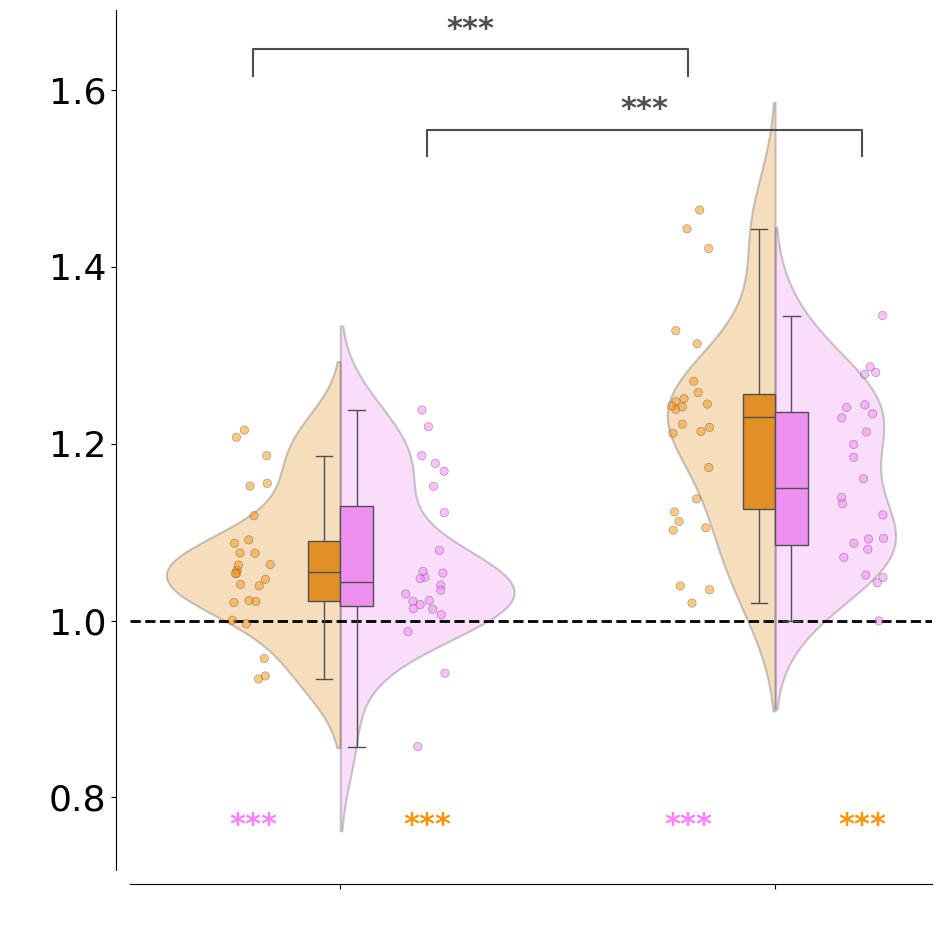

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import pandas as pd
import os
from scipy.stats import wilcoxon

# ============================================================
# 0. Load Data
# ============================================================

input_dir = './indiv_dvals/'
slsqp = True  # Toggle this to apply/remove monotonic constraints

if slsqp:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_slsqp')
    solver_method = 'SLSQP'
else:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_NOslsqp')
    solver_method = 'L-BFGS-B'

# Note: Ensure these files exist or wrap them appropriately
df_bif = pd.read_csv(os.path.join(output_dir, 'bifScore.csv'))
df_auc = pd.read_csv(os.path.join(output_dir, 'prediction_auc.csv'))
df_trials = pd.read_csv(os.path.join(output_dir, 'trials.csv'))

# ============================================================
# 1. Figure Parameters (Homogenized)
# ============================================================
FS_TITLE  = 24
FS_LABEL  = 24
FS_AXIS_LABEL = FS_LABEL
FS_TICK   = 26
FS_LEGEND = 16
FS_STARS  = 22 
FS_PVAL   = 14   

PALETTE   = {'active': '#FF9408', 'passive': '#FD80FF'}
ROI_ORDER = ['A1', 'NoA1']
SHOW_PVAL_MODE = '1'
VIOLIN_ALPHA  = 0.3
STRIP_ALPHA   = 0.5
STRIP_SIZE    = 6

plt.rcParams.update({
    'font.size':         FS_TICK,
    'axes.labelsize':    FS_LABEL,
    'axes.titlesize':    FS_TITLE,
    'xtick.labelsize':   FS_TICK,
    'ytick.labelsize':   FS_TICK,
    'legend.fontsize':   FS_LEGEND,
})

# ============================================================
# 2. Helper Functions
# ============================================================

def get_sig_star(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def format_pval_label(p1, p2, mode):
    return f'p={p1:.3f}' if p1 >= 0.001 else 'p<.001'

def add_bracket(ax, x1, x2, y, h, p1, p2, mode=SHOW_PVAL_MODE):
    star  = get_sig_star(p1)
    label =  ' ' 
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='black')
    ax.text((x1+x2)*.5, y+h, star, ha='center', va='bottom',
            fontsize=FS_STARS, fontweight='bold')
    ax.text((x1+x2)*.5, y+h*2.5, label, ha='center', va='bottom',
            fontsize=FS_PVAL, fontstyle='italic')

def get_paired(df, col_group, val_group1, val_group2, col_subj, col_score, col_filter=None, filter_val=None):
    if col_filter:
        df = df[df[col_filter] == filter_val]
    common = (set(df[df[col_group] == val_group1][col_subj]) &
              set(df[df[col_group] == val_group2][col_subj]))
    a = df[(df[col_group]==val_group1) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    b = df[(df[col_group]==val_group2) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    return a, b

# ============================================================
# 3. Figure 1: Bifurcation Score
# ============================================================

def plot_bifurcation_only(df):
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.violinplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, split=True, inner=None, palette=PALETTE, alpha=VIOLIN_ALPHA, ax=ax, legend=False)
    sns.boxplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, width=0.15, zorder=10, palette=PALETTE, showfliers=False, ax=ax, legend=False)
    sns.stripplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, dodge=True, alpha=STRIP_ALPHA, palette=PALETTE, size=STRIP_SIZE, ax=ax, legend=False)

    ax.axhline(0, color='black', alpha=0.6, lw=2, linestyle='--')
    y_min, y_max = df['score'].min(), df['score'].max()
    pad = (y_max - y_min) * 0.1

    for i, roi in enumerate(ROI_ORDER):
        alt = 'less' if roi == 'A1' else 'greater'
        for j, task in enumerate(['active', 'passive']):
            vals = df[(df['roi']==roi) & (df['task']==task)]['score'].dropna().values
            if len(vals) == 0: continue
            if np.any(vals != 0):
                _, p1 = wilcoxon(vals, alternative=alt)
                star = get_sig_star(p1)
            else:
                star = 'ns'
            x_pos = i - 0.2 if j == 0 else i + 0.2
            ax.text(x_pos, y_min - pad*1.2, star, ha='center', va='top', fontsize=FS_STARS, fontweight='bold', color=PALETTE[task])

    for j, task in enumerate(['active', 'passive']):
        a1, no = get_paired(df, 'roi', 'A1', 'NoA1', 'subj', 'score', col_filter='task', filter_val=task)
        if len(a1) == 0: continue
        if np.any(no - a1 != 0):
            _, p1 = wilcoxon(no, a1, alternative='greater')
            x_off = -0.2 if j == 0 else 0.2
            add_bracket(ax, 0+x_off, 1+x_off, y_max + pad*(1 + j*3), pad*0.5, p1, None)

    plt.ylabel(' ', fontsize=FS_AXIS_LABEL)
    plt.xlabel(' ', fontsize=FS_AXIS_LABEL)
    frame1 = plt.gca()
    frame1.axes.xaxis.set_ticklabels([])
    sns.despine(offset=10)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_bifurcation2.png'))
    plt.show()

# ============================================================
# 4. Figure 2: AUC Task Comparison
# ============================================================

def plot_auc_comparison(df_auc):
    TASK_ORDER = ['active', 'passive']
    fig, ax = plt.subplots(figsize=(10, 10)) 
    sns.violinplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, inner=None, alpha=VIOLIN_ALPHA, ax=ax)
    sns.boxplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, width=0.2, palette=PALETTE, showfliers=False, ax=ax)
    sns.stripplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, alpha=STRIP_ALPHA, ax=ax)
    ax.axhline(0.5, color='black', ls='--', lw=2)

    y_min, y_max = df_auc['auc'].min(), df_auc['auc'].max()
    pad = (y_max - y_min) * 0.1

    plt.ylabel(' ')
    plt.xlabel(' ')
    frame1 = plt.gca()
    frame1.axes.xaxis.set_ticklabels([])

    act, pas = get_paired(df_auc, 'task', 'active', 'passive', 'subj', 'auc')
    if len(act) > 0 and np.any(act - pas != 0):
        _, p1 = wilcoxon(act, pas, alternative='greater')
        add_bracket(ax, 0, 1, y_max + pad*1.5, pad*0.5, p1, None)
    
    sns.despine(offset=10)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_auc_task_compare2.png'))
    plt.show()

# ============================================================
# 5. Figure 3: Posterior Distributions
# ============================================================

def plot_posteriors(df_trials):
    fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    df_trials['Report'] = df_trials['HnotH'].map({1.0: 'Heard', 0.0: 'Not Heard'})
    
    for i, task in enumerate(['active', 'passive']):
        sub = df_trials[df_trials['task'] == task]
        sns.kdeplot(data=sub, x='post_high', hue='Report', fill=True,
                    palette={'Heard': '#2ca02c', 'Not Heard': '#d62728'},
                    common_norm=False, ax=axes[i], alpha=0.4, lw=3,
                    legend=False)
        
        axes[i].set_title("")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].yaxis.set_ticklabels([])
        axes[i].xaxis.set_ticklabels([])

    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_posterior_distributions3.png'))
    plt.show()

# ============================================================
# Run Initial Plots
# ============================================================
'''plot_bifurcation_only(df_bif)
plot_auc_comparison(df_auc)
plot_posteriors(df_trials)'''


# ============================================================
# 6. Figure 4: VPR Plot (Updated with Wilcoxon Comparisons)
# ============================================================
df_vpr = pd.read_csv('all_vpr_scores_all.csv')
roi_map = {'A1': 'Primary Audit.', 'NoA1': 'Beyond Primary Audit.'}
df_vpr['roi'] = df_vpr['roi'].map(roi_map)

roi_order = ['Primary Audit.', 'Beyond Primary Audit.']
task_order = ['active', 'passive']
palette = {'active': '#FF9408', 'passive': '#FD80FF'}

def add_stats_bracket_vpr(ax, x1, x2, y, text):
    h = (df_vpr['vpr_score'].max() - df_vpr['vpr_score'].min()) * 0.05
    ax.plot([x1, x1, x2, x2], [y-h, y, y, y-h], lw=1.5, c='0.3')
    ax.text((x1+x2)*.5, y + (h*0.2), text, ha='center', va='bottom', 
            color='0.3', fontsize=FS_STARS, fontweight='bold')

plt.figure(figsize=(10, 10))

ax = sns.violinplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,
    split=True, inner=None, palette=palette, alpha=VIOLIN_ALPHA, linewidth=1.5, legend=False)

sns.boxplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,
    width=0.15, zorder=10, palette=palette, showcaps=True, showfliers=False, ax=ax, legend=False)

for patch in ax.patches:
    if isinstance(patch, plt.Polygon):
        patch.set_facecolor('none')
        patch.set_edgecolor('0.3')

sns.stripplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,
    dodge=True, jitter=True, alpha=STRIP_ALPHA, palette=palette, size=STRIP_SIZE, edgecolor='gray', linewidth=0.5, ax=ax, legend=False)

# --- Stat Implementation 1: Paired ROI Comparison via Wilcoxon ---
y_max = df_vpr['vpr_score'].max()
y_min = df_vpr['vpr_score'].min()
pad_vpr = (y_max - y_min) * 0.1

for task_idx, task in enumerate(task_order):
    g1 = df_vpr[(df_vpr['roi'] == roi_order[0]) & (df_vpr['task'] == task)]['vpr_score'].dropna().values
    g2 = df_vpr[(df_vpr['roi'] == roi_order[1]) & (df_vpr['task'] == task)]['vpr_score'].dropna().values
    
    if len(g1) == len(g2) and len(g1) > 0 and np.any(g1 - g2 != 0):
        _, p_val = wilcoxon(g1, g2)
        star_text = get_sig_star(p_val)
    else:
        star_text = 'ns'
        
    x1, x2 = (0 - 0.2 if task == 'passive' else 0 + 0.2), (1 - 0.2 if task == 'passive' else 1 + 0.2)
    bracket_y = y_max + pad_vpr * (1.5 + task_idx * 1.5)
    add_stats_bracket_vpr(ax, x1, x2, bracket_y, star_text)

# --- Stat Implementation 2: One-Sample Wilcoxon Test vs Baseline (1) ---
for i, roi in enumerate(roi_order):
    for task in task_order:
        vals = df_vpr[(df_vpr['roi'] == roi) & (df_vpr['task'] == task)]['vpr_score'].dropna().values
        if len(vals) == 0: continue
        
        # Subtracting baseline value 1 to evaluate against 0 
        if np.any(vals - 1 != 0):
            _, p_vs1 = wilcoxon(vals - 1)
            star_vs1 = get_sig_star(p_vs1)
        else:
            star_vs1 = 'ns'
            
        # Match horizontal alignment with the split-violin dodging convention
        x_pos = i - 0.2 if task == 'passive' else i + 0.2
        
        # Plot stars underneath the distributions cleanly coded by group color
        ax.text(x_pos, y_min - pad_vpr * 1.2, star_vs1, ha='center', va='top', 
                fontsize=FS_STARS, fontweight='bold', color=palette[task])

ax.axhline(1, color='black', ls='--', lw=2)
plt.ylabel(' ', fontsize=FS_AXIS_LABEL)
plt.xlabel(' ', fontsize=FS_AXIS_LABEL)
plt.gca().axes.xaxis.set_ticklabels([])
sns.despine(offset=10)
plt.tight_layout()
plt.savefig('grp_comparison_VPR3.png', dpi=300)
plt.show()

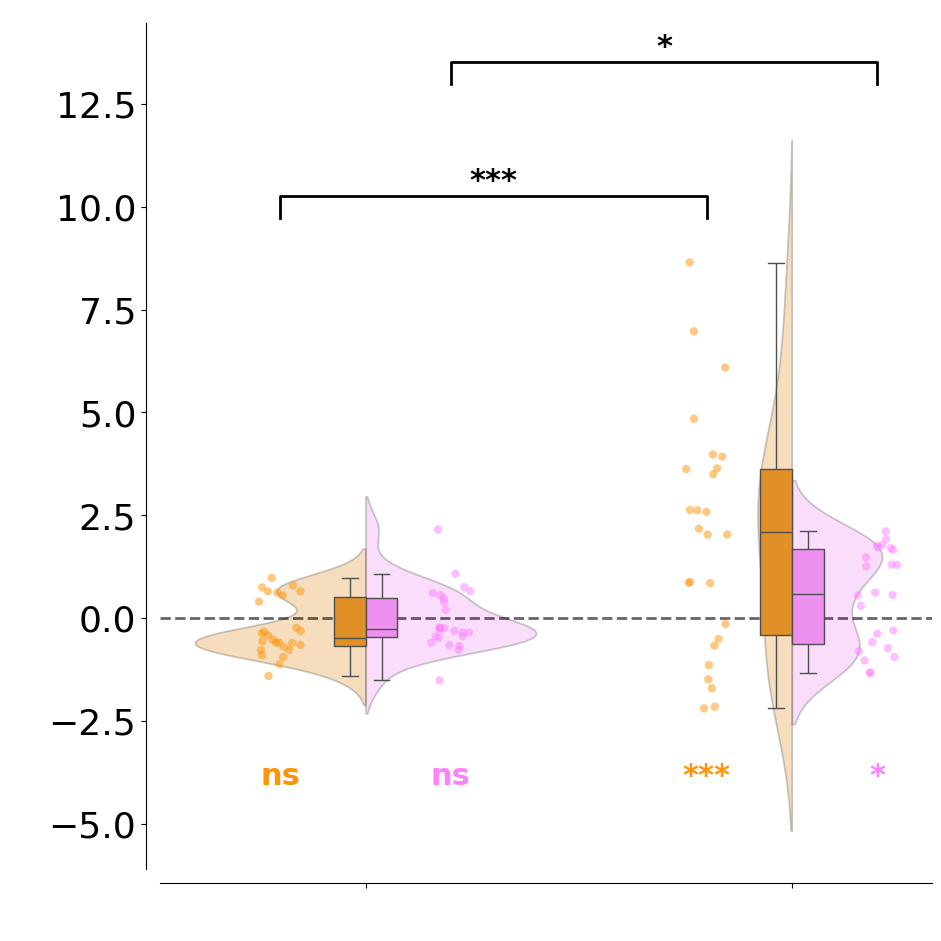

/tmp/ipykernel_50540/2885822808.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, inner=None, alpha=VIOLIN_ALPHA, ax=ax)
/tmp/ipykernel_50540/2885822808.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, width=0.2, palette=PALETTE, showfliers=False, ax=ax)
/tmp/ipykernel_50540/2885822808.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, alpha=ST

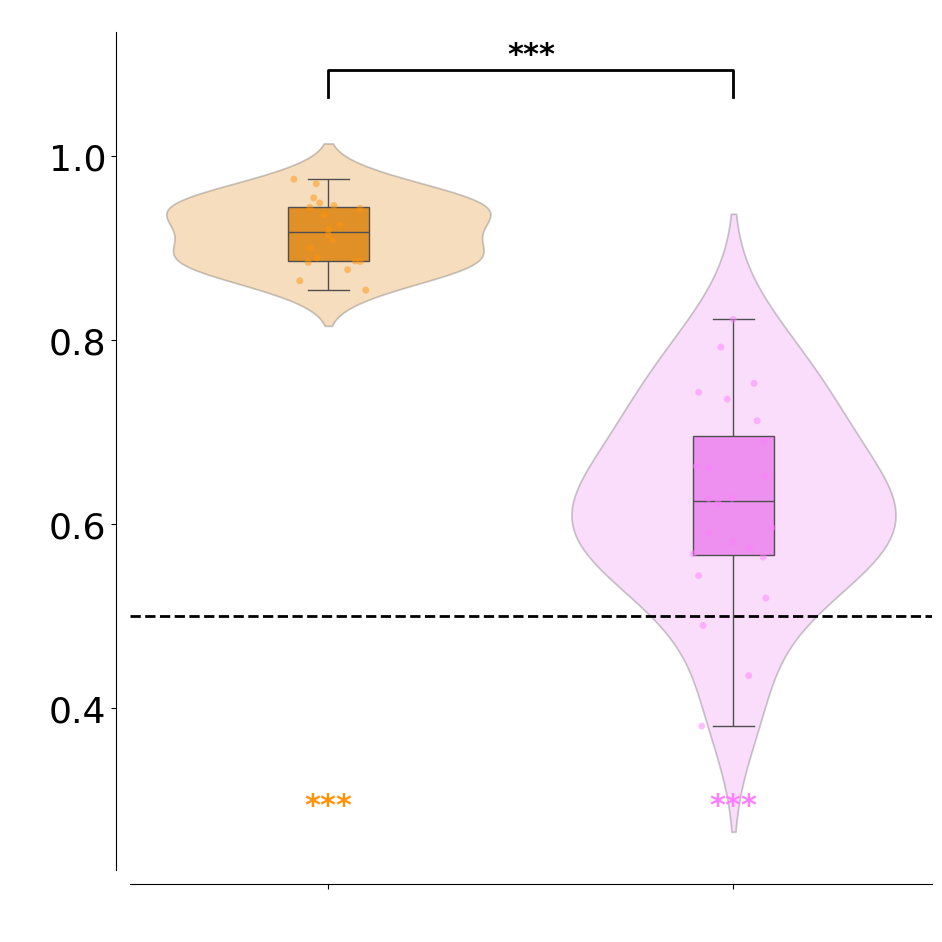

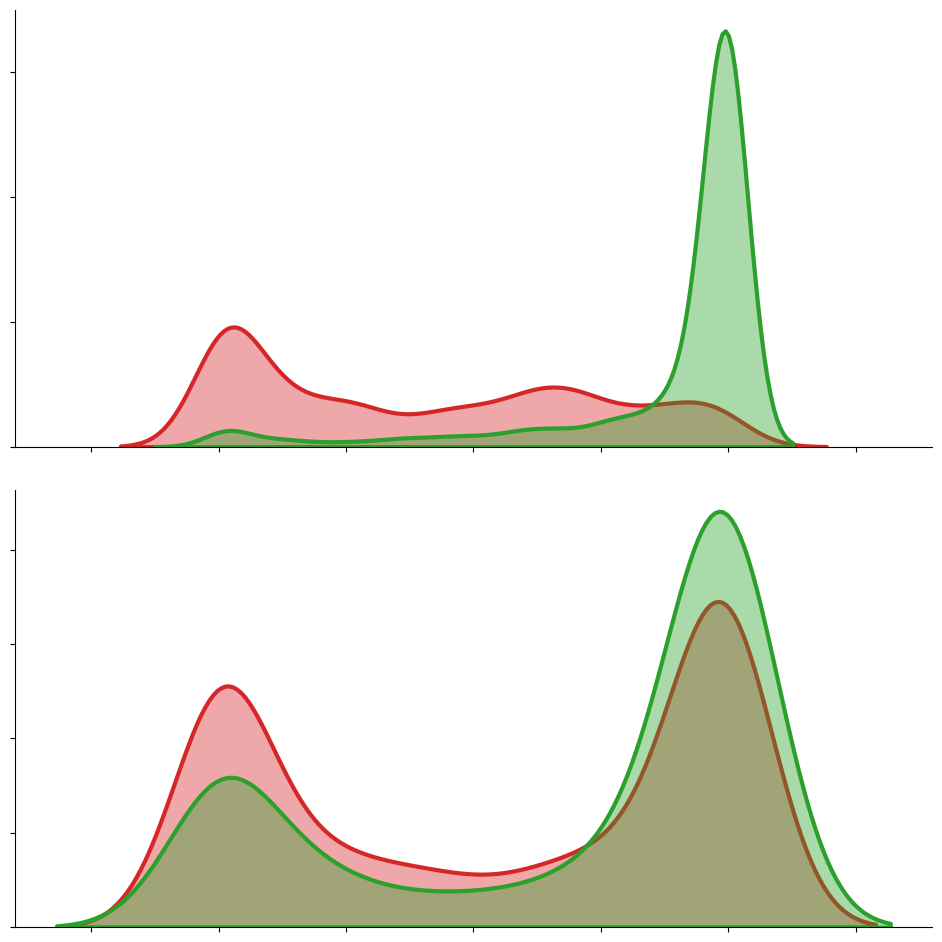

/tmp/ipykernel_50540/2885822808.py:239: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,


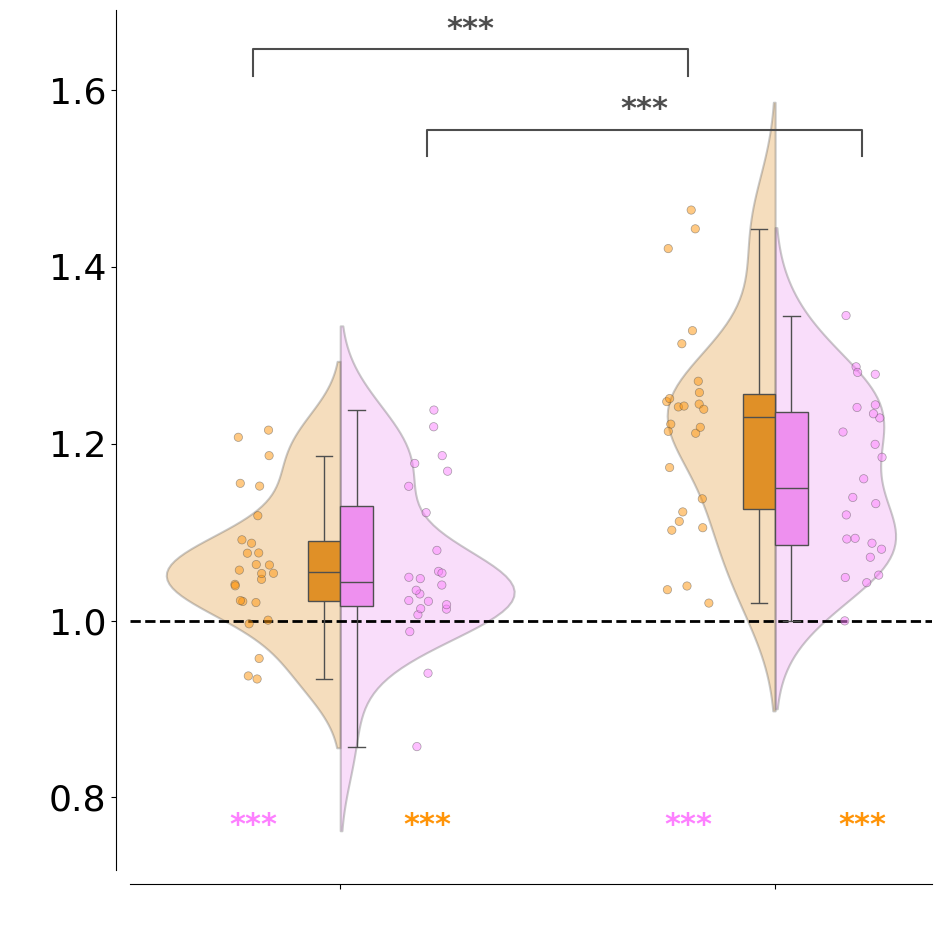

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import pandas as pd
import os
from scipy.stats import wilcoxon

# ============================================================
# 0. Load Data
# ============================================================

input_dir = './indiv_dvals/'
slsqp = True  # Toggle this to apply/remove monotonic constraints

if slsqp:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_slsqp')
    solver_method = 'SLSQP'
else:
    output_dir = os.path.join(os.getcwd(), 'v7_lambda10_NOslsqp')
    solver_method = 'L-BFGS-B'

df_bif = pd.read_csv(os.path.join(output_dir, 'bifScore.csv'))
df_auc = pd.read_csv(os.path.join(output_dir, 'prediction_auc.csv'))
df_trials = pd.read_csv(os.path.join(output_dir, 'trials.csv'))

# ============================================================
# 1. Figure Parameters (Homogenized)
# ============================================================
FS_TITLE  = 24
FS_LABEL  = 24
FS_AXIS_LABEL = FS_LABEL
FS_TICK   = 26
FS_LEGEND = 16
FS_STARS  = 22 
FS_PVAL   = 14   

PALETTE   = {'active': '#FF9408', 'passive': '#FD80FF'}
ROI_ORDER = ['A1', 'NoA1']
SHOW_PVAL_MODE = '1'
VIOLIN_ALPHA  = 0.3
STRIP_ALPHA   = 0.5
STRIP_SIZE    = 6

plt.rcParams.update({
    'font.size':         FS_TICK,
    'axes.labelsize':    FS_LABEL,
    'axes.titlesize':    FS_TITLE,
    'xtick.labelsize':   FS_TICK,
    'ytick.labelsize':   FS_TICK,
    'legend.fontsize':   FS_LEGEND,
})

# ============================================================
# 2. Helper Functions
# ============================================================

def get_sig_star(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def format_pval_label(p1, p2, mode):
    return f'p={p1:.3f}' if p1 >= 0.001 else 'p<.001'

def add_bracket(ax, x1, x2, y, h, p1, p2, mode=SHOW_PVAL_MODE):
    star  = get_sig_star(p1)
    label =  ' ' 
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='black')
    ax.text((x1+x2)*.5, y+h, star, ha='center', va='bottom',
            fontsize=FS_STARS, fontweight='bold')
    ax.text((x1+x2)*.5, y+h*2.5, label, ha='center', va='bottom',
            fontsize=FS_PVAL, fontstyle='italic')

def get_paired(df, col_group, val_group1, val_group2, col_subj, col_score, col_filter=None, filter_val=None):
    if col_filter:
        df = df[df[col_filter] == filter_val]
    common = (set(df[df[col_group] == val_group1][col_subj]) &
              set(df[df[col_group] == val_group2][col_subj]))
    a = df[(df[col_group]==val_group1) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    b = df[(df[col_group]==val_group2) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    return a, b

# ============================================================
# 3. Figure 1: Bifurcation Score
# ============================================================

def plot_bifurcation_only(df):
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.violinplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, split=True, inner=None, palette=PALETTE, alpha=VIOLIN_ALPHA, ax=ax, legend=False)
    sns.boxplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, width=0.15, zorder=10, palette=PALETTE, showfliers=False, ax=ax, legend=False)
    sns.stripplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, dodge=True, alpha=STRIP_ALPHA, palette=PALETTE, size=STRIP_SIZE, ax=ax, legend=False)

    ax.axhline(0, color='black', alpha=0.6, lw=2, linestyle='--')
    y_min, y_max = df['score'].min(), df['score'].max()
    pad = (y_max - y_min) * 0.1

    for i, roi in enumerate(ROI_ORDER):
        alt = 'less' if roi == 'A1' else 'greater'
        for j, task in enumerate(['active', 'passive']):
            vals = df[(df['roi']==roi) & (df['task']==task)]['score'].dropna().values
            if len(vals) == 0: continue
            if np.any(vals != 0):
                _, p1 = wilcoxon(vals, alternative=alt)
                star = get_sig_star(p1)
            else:
                star = 'ns'
            x_pos = i - 0.2 if j == 0 else i + 0.2
            ax.text(x_pos, y_min - pad*1.2, star, ha='center', va='top', fontsize=FS_STARS, fontweight='bold', color=PALETTE[task])

    for j, task in enumerate(['active', 'passive']):
        a1, no = get_paired(df, 'roi', 'A1', 'NoA1', 'subj', 'score', col_filter='task', filter_val=task)
        if len(a1) == 0: continue
        if np.any(no - a1 != 0):
            _, p1 = wilcoxon(no, a1, alternative='greater')
            x_off = -0.2 if j == 0 else 0.2
            add_bracket(ax, 0+x_off, 1+x_off, y_max + pad*(1 + j*3), pad*0.5, p1, None)

    plt.ylabel(' ', fontsize=FS_AXIS_LABEL)
    plt.xlabel(' ', fontsize=FS_AXIS_LABEL)
    frame1 = plt.gca()
    frame1.axes.xaxis.set_ticklabels([])
    sns.despine(offset=10)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_bifurcation12.png'))
    plt.show()

# ============================================================
# 4. Figure 2: AUC Task Comparison (Updated with baseline test)
# ============================================================

def plot_auc_comparison(df_auc):
    TASK_ORDER = ['active', 'passive']
    fig, ax = plt.subplots(figsize=(10, 10)) 
    sns.violinplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, inner=None, alpha=VIOLIN_ALPHA, ax=ax)
    sns.boxplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, width=0.2, palette=PALETTE, showfliers=False, ax=ax)
    sns.stripplot(data=df_auc, x='task', y='auc', order=TASK_ORDER, palette=PALETTE, alpha=STRIP_ALPHA, ax=ax)
    ax.axhline(0.5, color='black', ls='--', lw=2)

    y_min, y_max = df_auc['auc'].min(), df_auc['auc'].max()
    pad = (y_max - y_min) * 0.1

    plt.ylabel(' ')
    plt.xlabel(' ')
    frame1 = plt.gca()
    frame1.axes.xaxis.set_ticklabels([])

    # --- Stat Implementation 1: Paired task comparison ---
    act, pas = get_paired(df_auc, 'task', 'active', 'passive', 'subj', 'auc')
    if len(act) > 0 and np.any(act - pas != 0):
        _, p1 = wilcoxon(act, pas, alternative='greater')
        add_bracket(ax, 0, 1, y_max + pad*1.5, pad*0.5, p1, None)
    
    # --- Stat Implementation 2: One-Sample Wilcoxon Test vs Baseline (0.5) ---
    for i, task in enumerate(TASK_ORDER):
        vals = df_auc[df_auc['task'] == task]['auc'].dropna().values
        if len(vals) == 0: continue
        
        if np.any(vals - 0.5 != 0):
            _, p_vs05 = wilcoxon(vals - 0.5)
            star_vs05 = get_sig_star(p_vs05)
        else:
            star_vs05 = 'ns'
            
        # Place stars directly beneath each categorical condition column
        ax.text(i, y_min - pad * 1.2, star_vs05, ha='center', va='top', 
                fontsize=FS_STARS, fontweight='bold', color=PALETTE[task])

    sns.despine(offset=10)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_auc_task_compare12.png'))
    plt.show()

# ============================================================
# 5. Figure 3: Posterior Distributions
# ============================================================

def plot_posteriors(df_trials):
    fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    df_trials['Report'] = df_trials['HnotH'].map({1.0: 'Heard', 0.0: 'Not Heard'})
    
    for i, task in enumerate(['active', 'passive']):
        sub = df_trials[df_trials['task'] == task]
        sns.kdeplot(data=sub, x='post_high', hue='Report', fill=True,
                    palette={'Heard': '#2ca02c', 'Not Heard': '#d62728'},
                    common_norm=False, ax=axes[i], alpha=0.4, lw=3,
                    legend=False)
        
        axes[i].set_title("")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].yaxis.set_ticklabels([])
        axes[i].xaxis.set_ticklabels([])

    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'group_posterior_distributions12.png'))
    plt.show()

# ============================================================
# Run Initial Plots
# ============================================================
plot_bifurcation_only(df_bif)
plot_auc_comparison(df_auc)
plot_posteriors(df_trials)


# ============================================================
# 6. Figure 4: VPR Plot
# ============================================================
df_vpr = pd.read_csv('all_vpr_scores_all.csv')
roi_map = {'A1': 'Primary Audit.', 'NoA1': 'Beyond Primary Audit.'}
df_vpr['roi'] = df_vpr['roi'].map(roi_map)

roi_order = ['Primary Audit.', 'Beyond Primary Audit.']
task_order = ['active', 'passive']
palette = {'active': '#FF9408', 'passive': '#FD80FF'}

def add_stats_bracket_vpr(ax, x1, x2, y, text):
    h = (df_vpr['vpr_score'].max() - df_vpr['vpr_score'].min()) * 0.05
    ax.plot([x1, x1, x2, x2], [y-h, y, y, y-h], lw=1.5, c='0.3')
    ax.text((x1+x2)*.5, y + (h*0.2), text, ha='center', va='bottom', 
            color='0.3', fontsize=FS_STARS, fontweight='bold')

plt.figure(figsize=(10, 10))

ax = sns.violinplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,
    split=True, inner=None, palette=palette, alpha=VIOLIN_ALPHA, linewidth=1.5, legend=False)

sns.boxplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,
    width=0.15, zorder=10, palette=palette, showcaps=True, showfliers=False, ax=ax, legend=False)

for patch in ax.patches:
    if isinstance(patch, plt.Polygon):
        patch.set_facecolor('none')
        patch.set_edgecolor('0.3')

sns.stripplot(data=df_vpr, x='roi', y='vpr_score', hue='task', hue_order=task_order, order=roi_order,
    dodge=True, jitter=True, alpha=STRIP_ALPHA, palette=palette, size=STRIP_SIZE, edgecolor='gray', linewidth=0.5, ax=ax, legend=False)

# --- Stat Implementation 1: Paired ROI Comparison via Wilcoxon ---
y_max = df_vpr['vpr_score'].max()
y_min = df_vpr['vpr_score'].min()
pad_vpr = (y_max - y_min) * 0.1

for task_idx, task in enumerate(task_order):
    g1 = df_vpr[(df_vpr['roi'] == roi_order[0]) & (df_vpr['task'] == task)]['vpr_score'].dropna().values
    g2 = df_vpr[(df_vpr['roi'] == roi_order[1]) & (df_vpr['task'] == task)]['vpr_score'].dropna().values
    
    if len(g1) == len(g2) and len(g1) > 0 and np.any(g1 - g2 != 0):
        _, p_val = wilcoxon(g1, g2)
        star_text = get_sig_star(p_val)
    else:
        star_text = 'ns'
        
    x1, x2 = (0 - 0.2 if task == 'passive' else 0 + 0.2), (1 - 0.2 if task == 'passive' else 1 + 0.2)
    bracket_y = y_max + pad_vpr * (1.5 + task_idx * 1.5)
    add_stats_bracket_vpr(ax, x1, x2, bracket_y, star_text)

# --- Stat Implementation 2: One-Sample Wilcoxon Test vs Baseline (1) ---
for i, roi in enumerate(roi_order):
    for task in task_order:
        vals = df_vpr[(df_vpr['roi'] == roi) & (df_vpr['task'] == task)]['vpr_score'].dropna().values
        if len(vals) == 0: continue
        
        if np.any(vals - 1 != 0):
            _, p_vs1 = wilcoxon(vals - 1)
            star_vs1 = get_sig_star(p_vs1)
        else:
            star_vs1 = 'ns'
            
        x_pos = i - 0.2 if task == 'passive' else i + 0.2
        ax.text(x_pos, y_min - pad_vpr * 1.2, star_vs1, ha='center', va='top', 
                fontsize=FS_STARS, fontweight='bold', color=palette[task])

ax.axhline(1, color='black', ls='--', lw=2)
plt.ylabel(' ', fontsize=FS_AXIS_LABEL)
plt.xlabel(' ', fontsize=FS_AXIS_LABEL)
plt.gca().axes.xaxis.set_ticklabels([])
sns.despine(offset=10)
plt.tight_layout()
plt.savefig('grp_comparison_VPR12.png', dpi=300)
plt.show()

In [3]:
def report_all_statistical_results(df_bif, df_auc, df_vpr):
    stats_log = []

    # ============================================================
    # 1. Bifurcation Score Statistics
    # ============================================================
    # One-sample vs 0
    for roi in ROI_ORDER:
        alt = 'less' if roi == 'A1' else 'greater'
        for task in ['active', 'passive']:
            vals = df_bif[(df_bif['roi'] == roi) & (df_bif['task'] == task)]['score'].dropna().values
            if len(vals) > 0 and np.any(vals != 0):
                stat, p = wilcoxon(vals, alternative=alt)
                stats_log.append({
                    'Figure': 'Bifurcation Score', 'Test Type': f'One-Sample Wilcoxon (vs 0, alt={alt})',
                    'ROI': roi, 'Task/Condition': task, 'Statistic': stat, 'p-value': p
                })

    # Paired: NoA1 vs A1
    for task in ['active', 'passive']:
        a1, no = get_paired(df_bif, 'roi', 'A1', 'NoA1', 'subj', 'score', col_filter='task', filter_val=task)
        if len(a1) > 0 and np.any(no - a1 != 0):
            stat, p = wilcoxon(no, a1, alternative='greater')
            stats_log.append({
                'Figure': 'Bifurcation Score', 'Test Type': 'Paired Wilcoxon (NoA1 vs A1, alt=greater)',
                'ROI': 'A1 vs NoA1', 'Task/Condition': task, 'Statistic': stat, 'p-value': p
            })

    # ============================================================
    # 2. AUC Comparison Statistics
    # ============================================================
    # Paired: Active vs Passive
    act, pas = get_paired(df_auc, 'task', 'active', 'passive', 'subj', 'auc')
    if len(act) > 0 and np.any(act - pas != 0):
        stat, p = wilcoxon(act, pas, alternative='greater')
        stats_log.append({
            'Figure': 'AUC Comparison', 'Test Type': 'Paired Wilcoxon (Active vs Passive, alt=greater)',
            'ROI': 'N/A', 'Task/Condition': 'active vs passive', 'Statistic': stat, 'p-value': p
        })

    # One-sample vs 0.5
    for task in ['active', 'passive']:
        vals = df_auc[df_auc['task'] == task]['auc'].dropna().values
        if len(vals) > 0 and np.any(vals - 0.5 != 0):
            stat, p = wilcoxon(vals - 0.5)
            stats_log.append({
                'Figure': 'AUC Comparison', 'Test Type': 'One-Sample Wilcoxon (vs 0.5)',
                'ROI': 'N/A', 'Task/Condition': task, 'Statistic': stat, 'p-value': p
            })

    # ============================================================
    # 3. VPR Score Statistics
    # ============================================================
    # Copying data setup from your VPR section
    df_vpr_stat = df_vpr.copy()
    roi_map = {'A1': 'Primary Audit.', 'NoA1': 'Beyond Primary Audit.'}
    if 'roi' in df_vpr_stat.columns and not df_vpr_stat['roi'].str.contains('Audit.').any():
        df_vpr_stat['roi'] = df_vpr_stat['roi'].map(roi_map)
    
    vpr_rois = ['Primary Audit.', 'Beyond Primary Audit.']

    # Paired: ROI comparison
    for task in ['active', 'passive']:
        g1 = df_vpr_stat[(df_vpr_stat['roi'] == vpr_rois[0]) & (df_vpr_stat['task'] == task)]['vpr_score'].dropna().values
        g2 = df_vpr_stat[(df_vpr_stat['roi'] == vpr_rois[1]) & (df_vpr_stat['task'] == task)]['vpr_score'].dropna().values
        if len(g1) == len(g2) and len(g1) > 0 and np.any(g1 - g2 != 0):
            stat, p = wilcoxon(g1, g2)
            stats_log.append({
                'Figure': 'VPR Score', 'Test Type': 'Paired Wilcoxon (ROI Comparison)',
                'ROI': f'{vpr_rois[0]} vs {vpr_rois[1]}', 'Task/Condition': task, 'Statistic': stat, 'p-value': p
            })

    # One-sample vs 1
    for roi in vpr_rois:
        for task in ['active', 'passive']:
            vals = df_vpr_stat[(df_vpr_stat['roi'] == roi) & (df_vpr_stat['task'] == task)]['vpr_score'].dropna().values
            if len(vals) > 0 and np.any(vals - 1 != 0):
                stat, p = wilcoxon(vals - 1)
                stats_log.append({
                    'Figure': 'VPR Score', 'Test Type': 'One-Sample Wilcoxon (vs 1)',
                    'ROI': roi, 'Task/Condition': task, 'Statistic': stat, 'p-value': p
                })

    # Convert results to a DataFrame
    df_results = pd.DataFrame(stats_log)
    
    # Format for better scannability
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.float_format', lambda x: f'{x:.5f}' if x >= 0.0001 else f'{x:.5e}')
    
    print("\n" + "="*80)
    print("                      ALL STATISTICAL TEST RESULTS")
    print("="*80)
    print(df_results.to_string(index=False))
    print("="*80 + "\n")
    
    # Save results to output directory
    csv_out = os.path.join(output_dir, 'statistical_results_summary.csv')
    df_results.to_csv(csv_out, index=False)
    print(f"Results successfully saved to: {csv_out}")

# ============================================================
# Execution Trigger
# ============================================================
# Call this at the very bottom of your script
report_all_statistical_results(df_bif, df_auc, df_vpr)


                      ALL STATISTICAL TEST RESULTS
           Figure                                        Test Type                                     ROI    Task/Condition   Statistic     p-value
Bifurcation Score             One-Sample Wilcoxon (vs 0, alt=less)                                      A1            active   118.00000     0.07495
Bifurcation Score             One-Sample Wilcoxon (vs 0, alt=less)                                      A1           passive   134.00000     0.33172
Bifurcation Score          One-Sample Wilcoxon (vs 0, alt=greater)                                    NoA1            active   295.00000     0.00080
Bifurcation Score          One-Sample Wilcoxon (vs 0, alt=greater)                                    NoA1           passive   220.00000     0.02284
Bifurcation Score        Paired Wilcoxon (NoA1 vs A1, alt=greater)                              A1 vs NoA1            active   302.00000     0.00037
Bifurcation Score        Paired Wilcoxon (NoA1 vs A1, 

In [4]:
def report_stats_and_medians(df_bif, df_auc, df_vpr):
    stats_log = []
    medians_log = []

    # ============================================================
    # 1. Bifurcation Score Data
    # ============================================================
    # Medians
    for roi in ROI_ORDER:
        for task in ['active', 'passive']:
            vals = df_bif[(df_bif['roi'] == roi) & (df_bif['task'] == task)]['score'].dropna().values
            if len(vals) > 0:
                medians_log.append({'Figure': 'Bifurcation Score', 'ROI': roi, 'Task/Condition': task, 'Median Value': np.median(vals)})

    # Hypothesis Tests
    for roi in ROI_ORDER:
        alt = 'less' if roi == 'A1' else 'greater'
        for task in ['active', 'passive']:
            vals = df_bif[(df_bif['roi'] == roi) & (df_bif['task'] == task)]['score'].dropna().values
            if len(vals) > 0 and np.any(vals != 0):
                stat, p = wilcoxon(vals, alternative=alt)
                stats_log.append({
                    'Figure': 'Bifurcation Score', 'Test Type': f'One-Sample Wilcoxon (vs 0, alt={alt})',
                    'ROI': roi, 'Task/Condition': task, 'Statistic': stat, 'p-value': p
                })

    for task in ['active', 'passive']:
        a1, no = get_paired(df_bif, 'roi', 'A1', 'NoA1', 'subj', 'score', col_filter='task', filter_val=task)
        if len(a1) > 0 and np.any(no - a1 != 0):
            stat, p = wilcoxon(no, a1, alternative='greater')
            stats_log.append({
                'Figure': 'Bifurcation Score', 'Test Type': 'Paired Wilcoxon (NoA1 vs A1, alt=greater)',
                'ROI': 'A1 vs NoA1', 'Task/Condition': task, 'Statistic': stat, 'p-value': p
            })

    # ============================================================
    # 2. AUC Comparison Data
    # ============================================================
    # Medians
    for task in ['active', 'passive']:
        vals = df_auc[df_auc['task'] == task]['auc'].dropna().values
        if len(vals) > 0:
            medians_log.append({'Figure': 'AUC Comparison', 'ROI': 'N/A', 'Task/Condition': task, 'Median Value': np.median(vals)})

    # Hypothesis Tests
    act, pas = get_paired(df_auc, 'task', 'active', 'passive', 'subj', 'auc')
    if len(act) > 0 and np.any(act - pas != 0):
        stat, p = wilcoxon(act, pas, alternative='greater')
        stats_log.append({
            'Figure': 'AUC Comparison', 'Test Type': 'Paired Wilcoxon (Active vs Passive, alt=greater)',
            'ROI': 'N/A', 'Task/Condition': 'active vs passive', 'Statistic': stat, 'p-value': p
        })

    for task in ['active', 'passive']:
        vals = df_auc[df_auc['task'] == task]['auc'].dropna().values
        if len(vals) > 0 and np.any(vals - 0.5 != 0):
            stat, p = wilcoxon(vals - 0.5)
            stats_log.append({
                'Figure': 'AUC Comparison', 'Test Type': 'One-Sample Wilcoxon (vs 0.5)',
                'ROI': 'N/A', 'Task/Condition': task, 'Statistic': stat, 'p-value': p
            })

    # ============================================================
    # 3. VPR Score Data
    # ============================================================
    df_vpr_stat = df_vpr.copy()
    roi_map = {'A1': 'Primary Audit.', 'NoA1': 'Beyond Primary Audit.'}
    if 'roi' in df_vpr_stat.columns and not df_vpr_stat['roi'].str.contains('Audit.').any():
        df_vpr_stat['roi'] = df_vpr_stat['roi'].map(roi_map)
    vpr_rois = ['Primary Audit.', 'Beyond Primary Audit.']

    # Medians
    for roi in vpr_rois:
        for task in ['active', 'passive']:
            vals = df_vpr_stat[(df_vpr_stat['roi'] == roi) & (df_vpr_stat['task'] == task)]['vpr_score'].dropna().values
            if len(vals) > 0:
                medians_log.append({'Figure': 'VPR Score', 'ROI': roi, 'Task/Condition': task, 'Median Value': np.median(vals)})

    # Hypothesis Tests
    for task in ['active', 'passive']:
        g1 = df_vpr_stat[(df_vpr_stat['roi'] == vpr_rois[0]) & (df_vpr_stat['task'] == task)]['vpr_score'].dropna().values
        g2 = df_vpr_stat[(df_vpr_stat['roi'] == vpr_rois[1]) & (df_vpr_stat['task'] == task)]['vpr_score'].dropna().values
        if len(g1) == len(g2) and len(g1) > 0 and np.any(g1 - g2 != 0):
            stat, p = wilcoxon(g1, g2)
            stats_log.append({
                'Figure': 'VPR Score', 'Test Type': 'Paired Wilcoxon (ROI Comparison)',
                'ROI': f'{vpr_rois[0]} vs {vpr_rois[1]}', 'Task/Condition': task, 'Statistic': stat, 'p-value': p
            })

    for roi in vpr_rois:
        for task in ['active', 'passive']:
            vals = df_vpr_stat[(df_vpr_stat['roi'] == roi) & (df_vpr_stat['task'] == task)]['vpr_score'].dropna().values
            if len(vals) > 0 and np.any(vals - 1 != 0):
                stat, p = wilcoxon(vals - 1)
                stats_log.append({
                    'Figure': 'VPR Score', 'Test Type': 'One-Sample Wilcoxon (vs 1)',
                    'ROI': roi, 'Task/Condition': task, 'Statistic': stat, 'p-value': p
                })

    # ============================================================
    # Output Formatting & Saving
    # ============================================================
    df_medians = pd.DataFrame(medians_log)
    df_results = pd.DataFrame(stats_log)
    
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.float_format', lambda x: f'{x:.5f}' if x >= 0.0001 else f'{x:.5e}')
    
    # Print Medians Table
    print("\n" + "="*80)
    print("                      PLOTTED MEDIAN VALUES SUMMARY")
    print("="*80)
    print(df_medians.to_string(index=False))
    
    # Print Stats Table
    print("\n" + "="*80)
    print("                      ALL STATISTICAL TEST RESULTS")
    print("="*80)
    print(df_results.to_string(index=False))
    print("="*80 + "\n")
    
    # Save both dataframes to files
    df_medians.to_csv(os.path.join(output_dir, 'plotted_medians_summary.csv'), index=False)
    df_results.to_csv(os.path.join(output_dir, 'statistical_results_summary.csv'), index=False)
    print(f"Data saved to tracking CSVs in: {output_dir}")

# Call this at the very bottom of your script execution pipeline
report_stats_and_medians(df_bif, df_auc, df_vpr)


                      PLOTTED MEDIAN VALUES SUMMARY
           Figure                   ROI Task/Condition  Median Value
Bifurcation Score                    A1         active  -4.77095e-01
Bifurcation Score                    A1        passive  -2.61634e-01
Bifurcation Score                  NoA1         active       2.09806
Bifurcation Score                  NoA1        passive       0.58885
   AUC Comparison                   N/A         active       0.91785
   AUC Comparison                   N/A        passive       0.62569
        VPR Score        Primary Audit.         active       1.05520
        VPR Score        Primary Audit.        passive       1.04376
        VPR Score Beyond Primary Audit.         active       1.23051
        VPR Score Beyond Primary Audit.        passive       1.14976

                      ALL STATISTICAL TEST RESULTS
           Figure                                        Test Type                                     ROI    Task/Condition   Statistic